# Projet 9 — Analyse des ventes en ligne de Lapage

## 1. Contexte et objectifs de la mission

Lapage est une librairie initialement physique qui a développé une activité de vente en ligne depuis deux ans.  
L’entreprise souhaite aujourd’hui faire le point sur les performances de son site e-commerce afin de mieux comprendre son activité, ses ventes et le comportement de ses clients.

Cette analyse vise à identifier les principaux indicateurs de performance et à fournir des éléments d’aide à la décision pour la direction commerciale.

L’analyse s’articule autour de deux axes principaux :

- une analyse commerciale des ventes : chiffre d’affaires, évolution temporelle, catégories, transactions, clients et produits ;
- une analyse du comportement client : étude des liens entre certaines caractéristiques clients, notamment l’âge et le genre, et leurs comportements d’achat.

Les résultats devront être restitués de manière claire et synthétique dans un support destiné au CODIR, avec une attention particulière portée à l’interprétation business des résultats.

### Objectifs opérationnels

Les principaux objectifs sont les suivants :

- mesurer la performance globale de l’activité en ligne ;
- identifier les catégories et produits les plus contributeurs ;
- analyser la contribution et la concentration du chiffre d’affaires par client ;
- étudier les relations entre profil client et comportements d’achat ;
- formuler des recommandations exploitables pour orienter les actions marketing et commerciales.

## 2. Import des librairies

Les librairies nécessaires aux analyses statistiques sont importées dès le début du notebook afin d’être disponibles pour les tests réalisés dans les prochaines sections.

In [1]:
from pathlib import Path

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Tests statistiques
from scipy import stats
from scipy.stats import (
    shapiro,
    normaltest,
    pearsonr,
    spearmanr,
    chi2_contingency,
    fisher_exact,
    ttest_ind,
    f_oneway,
    mannwhitneyu,
    kruskal)

# Options d'affichage des DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Paramètres graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 3. Chargement des données

In [ ]:
# Les fichiers sources ne sont pas versionnés dans le dépôt.
# Les placer dans le dossier data/ avant de réexécuter le notebook.
DATA_DIR = Path("data")

customers = pd.read_csv(DATA_DIR / "customers.csv", sep=";")
products = pd.read_csv(DATA_DIR / "products.csv", sep=";")
transactions = pd.read_csv(
    DATA_DIR / "Transactions.csv",
    sep=";",
    dtype={
        "id_prod": str,
        "date": str,
        "session_id": str,
        "client_id": str})


### 3.1 Aperçu des données

Un premier aperçu des trois tables est réalisé afin de vérifier leur structure générale, les variables disponibles et le format des premières lignes.

In [3]:
print("Customers")
display(customers.head())

print("Products")
display(products.head())

print("Transactions")
display(transactions.head())

Customers


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


Products


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


Transactions


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


### 3.2 Structure des données

Après l’aperçu des premières lignes, la structure des tables est étudiée afin d’identifier le nombre de lignes et de colonnes, les types de variables et la présence éventuelle de valeurs manquantes.

In [4]:
print("Dimensions des tables :")
print(f"Customers : {customers.shape[0]} lignes et {customers.shape[1]} colonnes")
print(f"Products : {products.shape[0]} lignes et {products.shape[1]} colonnes")
print(f"Transactions : {transactions.shape[0]} lignes et {transactions.shape[1]} colonnes")

Dimensions des tables :
Customers : 8621 lignes et 3 colonnes
Products : 3286 lignes et 3 colonnes
Transactions : 1048575 lignes et 4 colonnes


In [5]:
print("Customers")
customers.info()

print("\nProducts")
products.info()

print("\nTransactions")
transactions.info()

Customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB

Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB

Transactions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        68

Les trois fichiers ont été chargés avec succès.  
La vérification de leur structure permet d’identifier les variables disponibles, leurs types et leur niveau de complétude avant la construction de la base d’analyse.

## 4. Contrôle qualité des données

Cette étape vérifie la cohérence générale des données avant leur exploitation : valeurs manquantes, lignes entièrement vides, doublons éventuels et cohérence des identifiants entre les tables.  
Le fichier de transactions comporte des lignes entièrement vides issues de l’export ; elles sont identifiées puis supprimées avant la consolidation, sans perte de transaction exploitable.


### 4.1 Vérification des valeurs manquantes

In [6]:
print("Valeurs manquantes - Customers")
display(customers.isna().sum())

print("\nValeurs manquantes - Products")
display(products.isna().sum())

print("\nValeurs manquantes - Transactions")
display(transactions.isna().sum())

Valeurs manquantes - Customers


client_id    0
sex          0
birth        0
dtype: int64


Valeurs manquantes - Products


id_prod    0
price      0
categ      0
dtype: int64


Valeurs manquantes - Transactions


id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

In [7]:
transactions_lignes_vides = transactions.isna().all(axis=1).sum()

print("Nombre de lignes entièrement vides dans Transactions :", transactions_lignes_vides)

Nombre de lignes entièrement vides dans Transactions : 361041


In [8]:
transactions = transactions.dropna(how="all")

In [9]:
print("Valeurs manquantes - Transactions après suppression des lignes vides")
display(transactions.isna().sum())

print("Dimensions de Transactions après suppression :", transactions.shape)

Valeurs manquantes - Transactions après suppression des lignes vides


id_prod       0
date          0
session_id    0
client_id     0
dtype: int64

Dimensions de Transactions après suppression : (687534, 4)


Les lignes entièrement vides du fichier des transactions sont retirées afin de conserver une base exploitable pour l’analyse.

### 4.2 Vérification des doublons

In [10]:
print("Doublons - Customers :", customers.duplicated().sum())
print("Doublons - Products :", products.duplicated().sum())
print("Doublons - Transactions :", transactions.duplicated().sum())

Doublons - Customers : 0
Doublons - Products : 0
Doublons - Transactions : 0


Le contrôle des doublons permet de vérifier qu’aucun enregistrement strictement identique ne risque de biaiser les indicateurs calculés.

### 4.3 Vérification des clés de jointure

In [11]:
clients_absents = transactions.loc[
    ~transactions["client_id"].isin(customers["client_id"]),
    "client_id"].nunique()

produits_absents = transactions.loc[
    ~transactions["id_prod"].isin(products["id_prod"]),
    "id_prod"].nunique()

print("Nombre de clients présents dans les transactions mais absents de la table customers :", clients_absents)
print("Nombre de produits présents dans les transactions mais absents de la table products :", produits_absents)

Nombre de clients présents dans les transactions mais absents de la table customers : 0
Nombre de produits présents dans les transactions mais absents de la table products : 0


Les clés de jointure sont vérifiées afin de s’assurer que les transactions peuvent être correctement reliées aux informations clients et produits.

## 5. Préparation de la base d’analyse

Les trois tables sont reliées afin de construire une base consolidée, utilisée pour le calcul des indicateurs de vente et l’analyse du comportement client.

### 5.1 Jointure des tables

In [12]:
# Jointure entre les transactions et les produits
df_ventes = transactions.merge(products, on="id_prod", how="left")

# Jointure avec les informations clients
df_ventes = df_ventes.merge(customers, on="client_id", how="left")

# Aperçu de la base consolidée
df_ventes.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956


In [13]:
print("Dimensions de la base consolidée :", df_ventes.shape)

Dimensions de la base consolidée : (687534, 8)


In [14]:
df_ventes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_prod     687534 non-null  object 
 1   date        687534 non-null  object 
 2   session_id  687534 non-null  object 
 3   client_id   687534 non-null  object 
 4   price       687534 non-null  float64
 5   categ       687534 non-null  int64  
 6   sex         687534 non-null  object 
 7   birth       687534 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 42.0+ MB


La base consolidée `df_ventes` regroupe les transactions enrichies avec les informations produits et clients.  
Elle servira de base principale pour les analyses.

### 5.2 Création des variables d’analyse

Plusieurs variables sont créées afin de faciliter les analyses temporelles, commerciales et clients : date, année, mois, âge du client et chiffre d’affaires.

In [15]:
# Conversion de la colonne date au format datetime
df_ventes["date"] = pd.to_datetime(df_ventes["date"])

# Création des variables temporelles
df_ventes["annee"] = df_ventes["date"].dt.year
df_ventes["mois"] = df_ventes["date"].dt.month
df_ventes["mois_annee"] = df_ventes["date"].dt.to_period("M")

# Création de l'âge du client
df_ventes["age"] = df_ventes["annee"] - df_ventes["birth"]

# Création du chiffre d'affaires
df_ventes["chiffre_affaires"] = df_ventes["price"]

In [16]:
df_ventes[[
    "date",
    "annee",
    "mois",
    "mois_annee",
    "birth",
    "age",
    "price",
    "chiffre_affaires"]].head()

,date,annee,mois,mois_annee,birth,age,price,chiffre_affaires
0,2021-03-01 00:01:07.843138,2021,3,2021-03,1967,54,11.99,11.99
1,2021-03-01 00:02:26.047414,2021,3,2021-03,1960,61,19.37,19.37
2,2021-03-01 00:02:38.311413,2021,3,2021-03,1988,33,4.50,4.50
3,2021-03-01 00:04:54.559692,2021,3,2021-03,1989,32,6.55,6.55
4,2021-03-01 00:05:18.801198,2021,3,2021-03,1956,65,16.49,16.49


Les variables créées permettent de préparer la base pour les analyses temporelles, commerciales et clients.

### 5.3 Vérification de la base d’analyse

Une dernière vérification de la base consolidée est réalisée afin de contrôler les variables créées, les dimensions de la table et la période couverte par les transactions.

In [17]:
# Aperçu de la base consolidée
df_ventes.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,annee,mois,mois_annee,age,chiffre_affaires
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,2021,3,2021-03,54,11.99
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,2021,3,2021-03,61,19.37
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,2021,3,2021-03,33,4.50
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,2021,3,2021-03,32,6.55
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,2021,3,2021-03,65,16.49


In [18]:
# Dimensions de la base consolidée
print(f"La base d'analyse contient {df_ventes.shape[0]} lignes et {df_ventes.shape[1]} colonnes.")

La base d'analyse contient 687534 lignes et 13 colonnes.


In [19]:
# Période couverte par les transactions
print("Date de début :", df_ventes["date"].min())
print("Date de fin :", df_ventes["date"].max())

Date de début : 2021-03-01 00:01:07.843138
Date de fin : 2023-02-28 23:58:30.792755


La base consolidée est désormais prête pour les analyses de ventes et de comportement client.

## 6. Analyse des ventes

Cette section analyse l’activité commerciale de Lapage à travers les principaux indicateurs de vente : chiffre d’affaires, transactions, clients, catégories et produits vendus.

### 6.1 Chiffre d’affaires global

Le chiffre d’affaires global est calculé sur l’ensemble de la période analysée.

In [20]:
ca_total = df_ventes["chiffre_affaires"].sum()

print(f"Chiffre d'affaires total : {ca_total:,.2f} €")

Chiffre d'affaires total : 12,027,663.10 €


Sur la période analysée, le chiffre d’affaires total s’élève à 12,03 M€.

### 6.2 Évolution du chiffre d’affaires dans le temps

L’évolution du chiffre d’affaires est étudiée par mois afin d’identifier les tendances générales de l’activité en ligne sur la période analysée.

In [21]:
ca_mensuel = (
    df_ventes
    .groupby("mois_annee")["chiffre_affaires"]
    .sum()
    .reset_index())

ca_mensuel["mois_annee"] = ca_mensuel["mois_annee"].astype(str)

display(ca_mensuel.head())

,mois_annee,chiffre_affaires
0,2021-03,482440.61
1,2021-04,476109.30
2,2021-05,492943.47
3,2021-06,484088.56
4,2021-07,482835.40


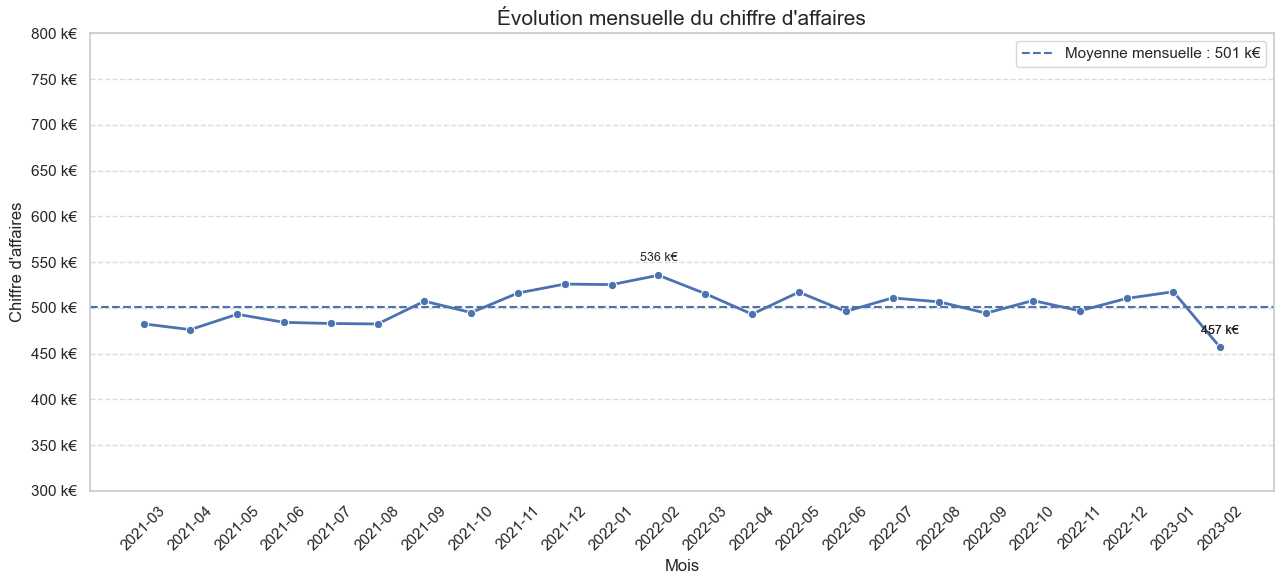

In [22]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=ca_mensuel,
    x="mois_annee",
    y="chiffre_affaires",
    marker="o",
    linewidth=2)

# Points à annoter : maximum, minimum et dernier mois
idx_max = ca_mensuel["chiffre_affaires"].idxmax()
idx_min = ca_mensuel["chiffre_affaires"].idxmin()
idx_last = ca_mensuel.index[-1]

for idx in [idx_max, idx_min, idx_last]:
    x = ca_mensuel.loc[idx, "mois_annee"]
    y = ca_mensuel.loc[idx, "chiffre_affaires"]
    
    plt.annotate(
        f"{y/1000:.0f} k€",
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9)

# Ligne de moyenne
moyenne_ca = ca_mensuel["chiffre_affaires"].mean()

plt.axhline(
    moyenne_ca,
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne mensuelle : {moyenne_ca/1000:.0f} k€")

# Échelle ajustée pour relativiser les variations
plt.ylim(300000, 800000)

# Format axe Y avec intervalles de 50 k€
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(50000))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

# Grille plus lisible : uniquement horizontale
plt.grid(axis="y", linestyle="--", linewidth=1, alpha=0.7)
plt.grid(axis="x", visible=False)

plt.title("Évolution mensuelle du chiffre d'affaires", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
df_ventes["date"].min(), df_ventes["date"].max()

(Timestamp('2021-03-01 00:01:07.843138'),
 Timestamp('2023-02-28 23:58:30.792755'))

In [24]:
df_ventes[df_ventes["mois_annee"] == "2023-02"]["date"].dt.date.nunique()

28

In [25]:
fevrier_2023 = df_ventes[df_ventes["mois_annee"] == "2023-02"]

resume_fevrier_2023 = pd.DataFrame({
    "indicateur": [
        "Chiffre d'affaires",
        "Nombre de lignes",
        "Nombre de sessions",
        "Nombre de clients"],
    "valeur": [
        fevrier_2023["chiffre_affaires"].sum(),
        fevrier_2023.shape[0],
        fevrier_2023["session_id"].nunique(),
        fevrier_2023["client_id"].nunique()]})

display(resume_fevrier_2023)

,indicateur,valeur
0,Chiffre d'affaires,456679.76
1,Nombre de lignes,25545.00
2,Nombre de sessions,13073.00
3,Nombre de clients,5587.00


Février 2023 couvre bien les 28 jours du mois.  
La baisse observée du chiffre d’affaires ne semble donc pas liée à un mois incomplet, mais plutôt à une variation de l’activité commerciale sur ce mois.

### 6.3 Moyenne mobile du chiffre d’affaires

Une moyenne mobile est calculée afin de lisser les variations mensuelles du chiffre d’affaires et de mieux observer la tendance générale de l’activité.

In [26]:
# Calcul de la moyenne mobile sur 3 mois
ca_mensuel["moyenne_mobile_3_mois"] = (
    ca_mensuel["chiffre_affaires"]
    .rolling(window=3)
    .mean())

display(ca_mensuel.head())

,mois_annee,chiffre_affaires,moyenne_mobile_3_mois
0,2021-03,482440.61,NaN
1,2021-04,476109.30,NaN
2,2021-05,492943.47,483831.13
3,2021-06,484088.56,484380.44
4,2021-07,482835.40,486622.48


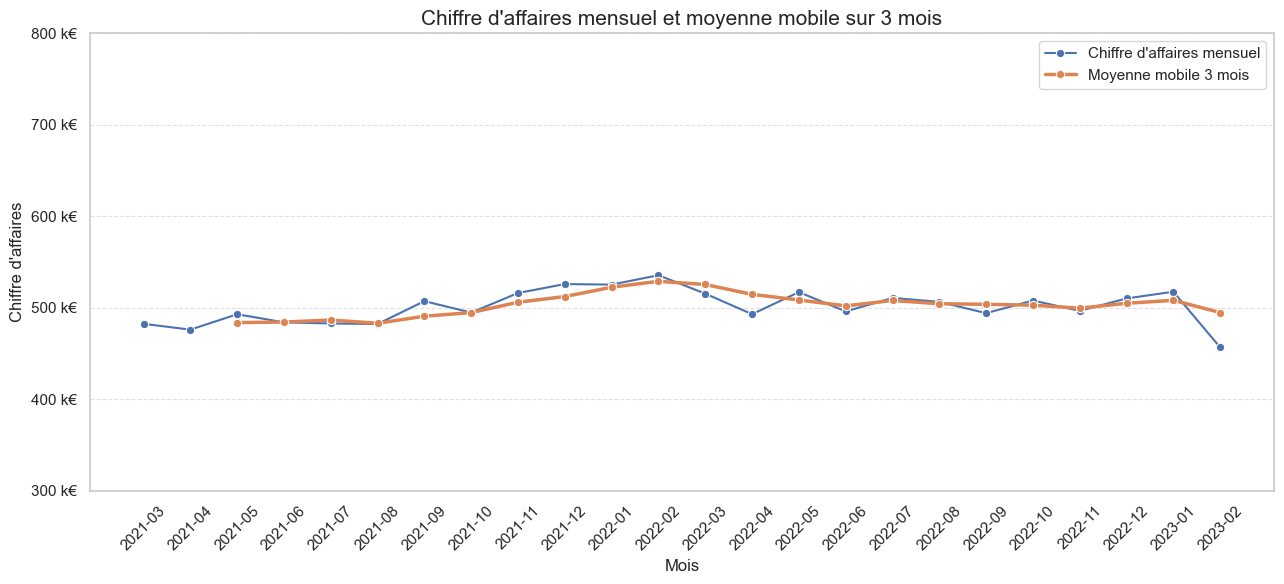

In [27]:
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=ca_mensuel,
    x="mois_annee",
    y="chiffre_affaires",
    marker="o",
    linewidth=1.5,
    label="Chiffre d'affaires mensuel")

sns.lineplot(
    data=ca_mensuel,
    x="mois_annee",
    y="moyenne_mobile_3_mois",
    marker="o",
    linewidth=2.5,
    label="Moyenne mobile 3 mois")

# Échelle ajustée pour relativiser les variations
plt.ylim(300000, 800000)

# Format axe Y
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(100000))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

# Grille : uniquement horizontale, un peu plus visible
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Chiffre d'affaires mensuel et moyenne mobile sur 3 mois", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

La moyenne mobile sur trois mois met en évidence une progression du chiffre d’affaires jusqu’au début de l’année 2022, suivie d’une évolution plus irrégulière.

### 6.4 Chiffre d’affaires par catégorie

Le chiffre d’affaires est ensuite analysé par catégorie de produits afin d’identifier les segments qui contribuent le plus à l’activité en ligne.

In [28]:
ca_par_categorie = (
    df_ventes
    .groupby("categ")["chiffre_affaires"]
    .sum()
    .reset_index()
    .sort_values(by="chiffre_affaires", ascending=False))

display(ca_par_categorie)

,categ,chiffre_affaires
1,1,4827657.11
0,0,4419730.97
2,2,2780275.02


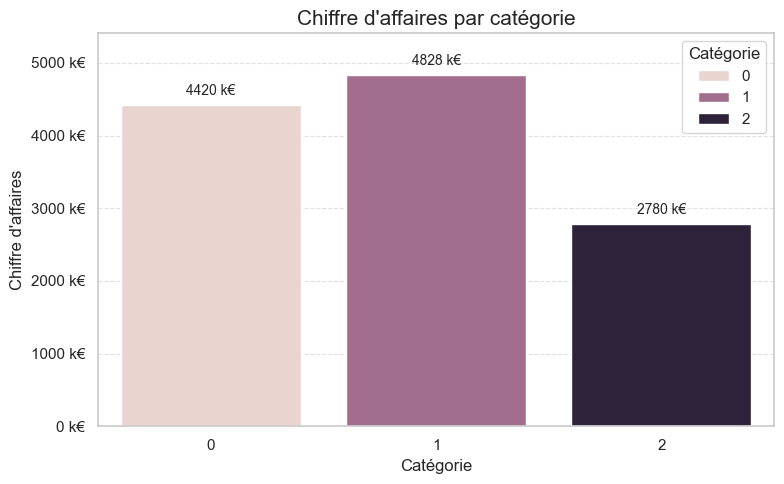

In [29]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=ca_par_categorie.sort_values("categ"),
    x="categ",
    y="chiffre_affaires",
    hue="categ",
    dodge=False)

# Format de l'axe Y en k€
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

# Ajout des labels sur toutes les barres
for container in ax.containers:
    labels = [
        f"{bar.get_height()/1000:.0f} k€"
        for bar in container
        if bar.get_height() > 0    ]
    
    ax.bar_label(
        container,
        labels=labels,
        padding=5,
        fontsize=10)

# Ajout d'une marge en haut pour éviter que les labels touchent le bord
ax.set_ylim(0, ca_par_categorie["chiffre_affaires"].max() * 1.12)

# Grille horizontale uniquement
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Chiffre d'affaires par catégorie", fontsize=15)
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires")

# Légende des catégories
plt.legend(
    title="Catégorie",
    loc="upper right")

plt.tight_layout()
plt.show()

L’analyse par catégorie montre que les catégories 1 et 0 sont les principales contributrices au chiffre d’affaires, tandis que la catégorie 2 présente une contribution plus limitée.

### 6.5 Nombre de transactions par mois

Le nombre de transactions est analysé à partir des sessions uniques afin de mesurer l’évolution du volume d’achats réalisés sur le site.

In [30]:
transactions_mensuelles = (
    df_ventes
    .groupby("mois_annee")["session_id"]
    .nunique()
    .reset_index()
    .rename(columns={"session_id": "nombre_transactions"}))

transactions_mensuelles["mois_annee"] = transactions_mensuelles["mois_annee"].astype(str)

display(transactions_mensuelles.head())

,mois_annee,nombre_transactions
0,2021-03,14201
1,2021-04,13970
2,2021-05,14168
3,2021-06,13838
4,2021-07,13571


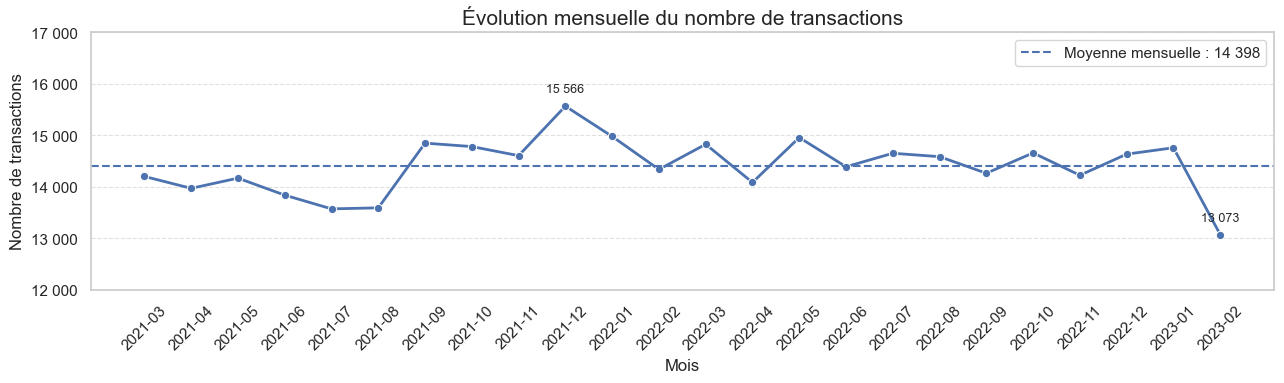

In [31]:
plt.figure(figsize=(13, 4))

sns.lineplot(
    data=transactions_mensuelles,
    x="mois_annee",
    y="nombre_transactions",
    marker="o",
    linewidth=2)

# Points à annoter : maximum et minimum
idx_max = transactions_mensuelles["nombre_transactions"].idxmax()
idx_min = transactions_mensuelles["nombre_transactions"].idxmin()

for idx in [idx_max, idx_min]:
    x = transactions_mensuelles.loc[idx, "mois_annee"]
    y = transactions_mensuelles.loc[idx, "nombre_transactions"]
    
    plt.annotate(
        f"{y:,.0f}".replace(",", " "),
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9)

# Ligne de moyenne
moyenne_transactions = transactions_mensuelles["nombre_transactions"].mean()

plt.axhline(
    moyenne_transactions,
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne mensuelle : {moyenne_transactions:,.0f}".replace(",", " "))

# Échelle ajustée pour relativiser les variations
plt.ylim(12000, 17000)

# Format axe Y avec intervalles de 1 000 transactions
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(1000))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ")))

# Grille : uniquement horizontale, un peu plus visible
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Évolution mensuelle du nombre de transactions", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

L’évolution du nombre de transactions permet de suivre le volume d’achats réalisés sur le site.  
Elle complète l’analyse du chiffre d’affaires en distinguant l’effet volume de l’évolution du panier moyen.

### 6.6 Chiffre d’affaires, transactions et panier moyen

Le chiffre d’affaires est mis en relation avec le nombre de transactions et le panier moyen afin de mieux comprendre les variations observées dans le temps.

In [32]:
indicateurs_mensuels = (
    df_ventes
    .groupby("mois_annee")
    .agg(
        chiffre_affaires=("chiffre_affaires", "sum"),
        nombre_transactions=("session_id", "nunique")    )
    .reset_index())

indicateurs_mensuels["panier_moyen"] = (
    indicateurs_mensuels["chiffre_affaires"] 
    / indicateurs_mensuels["nombre_transactions"])

indicateurs_mensuels["mois_annee"] = indicateurs_mensuels["mois_annee"].astype(str)

display(indicateurs_mensuels.head())

,mois_annee,chiffre_affaires,nombre_transactions,panier_moyen
0,2021-03,482440.61,14201,33.97
1,2021-04,476109.30,13970,34.08
2,2021-05,492943.47,14168,34.79
3,2021-06,484088.56,13838,34.98
4,2021-07,482835.40,13571,35.58


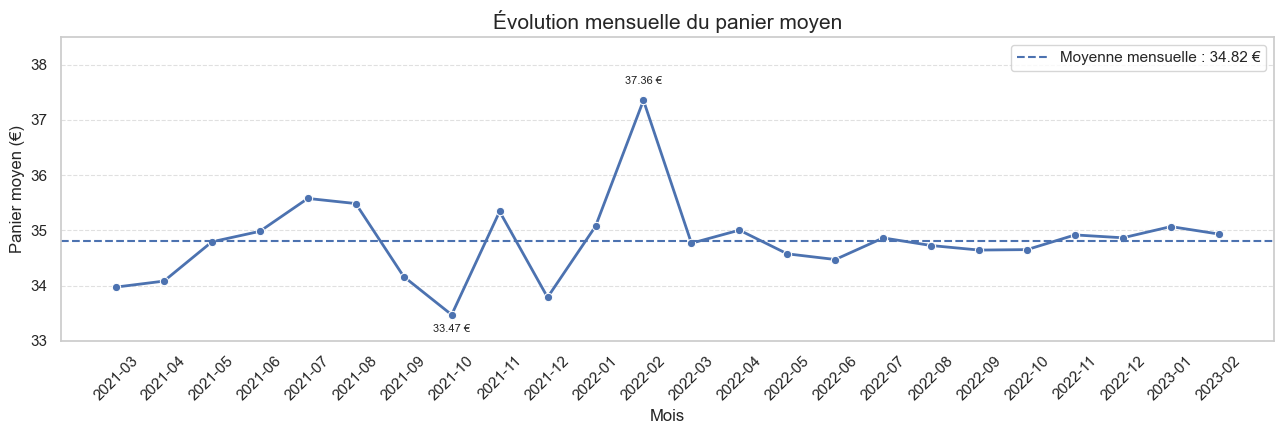

In [33]:
plt.figure(figsize=(13, 4.5))

ax = sns.lineplot(
    data=indicateurs_mensuels,
    x="mois_annee",
    y="panier_moyen",
    marker="o",
    linewidth=2)

# Points à annoter : maximum et minimum
idx_max = indicateurs_mensuels["panier_moyen"].idxmax()
idx_min = indicateurs_mensuels["panier_moyen"].idxmin()

for idx in [idx_max, idx_min]:
    x = indicateurs_mensuels.loc[idx, "mois_annee"]
    y = indicateurs_mensuels.loc[idx, "panier_moyen"]

 # Label au-dessus pour le maximum, en dessous pour le minimum
    offset = 10 if idx == idx_max else -7
    va = "bottom" if idx == idx_max else "top"
    
    plt.annotate(
        f"{y:.2f} €",
        xy=(x, y),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=8)

# Ligne de moyenne
moyenne_panier = indicateurs_mensuels["panier_moyen"].mean()

plt.axhline(
    moyenne_panier,
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne mensuelle : {moyenne_panier:.2f} €")

# Grille : uniquement horizontale
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

# Échelle ajustée pour laisser de l'espace aux annotations
plt.ylim(33, 38.5)

plt.title("Évolution mensuelle du panier moyen", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Panier moyen (€)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Le panier moyen reste relativement stable, autour de 34 € à 35 €.  
Les variations du chiffre d’affaires semblent donc davantage liées au volume de transactions qu’au montant moyen dépensé.

In [34]:
indicateurs_mensuels[
    indicateurs_mensuels["mois_annee"].isin(["2023-01", "2023-02"])]

,mois_annee,chiffre_affaires,nombre_transactions,panier_moyen
22,2023-01,517540.55,14758,35.07
23,2023-02,456679.76,13073,34.93


In [35]:
comparaison_jan_fev_2023 = indicateurs_mensuels[
    indicateurs_mensuels["mois_annee"].isin(["2023-01", "2023-02"])].copy()

comparaison_jan_fev_2023["variation_ca"] = comparaison_jan_fev_2023["chiffre_affaires"].pct_change()
comparaison_jan_fev_2023["variation_transactions"] = comparaison_jan_fev_2023["nombre_transactions"].pct_change()
comparaison_jan_fev_2023["variation_panier_moyen"] = comparaison_jan_fev_2023["panier_moyen"].pct_change()

display(comparaison_jan_fev_2023)

,mois_annee,chiffre_affaires,nombre_transactions,panier_moyen,variation_ca,variation_transactions,variation_panier_moyen
22,2023-01,517540.55,14758,35.07,NaN,NaN,NaN
23,2023-02,456679.76,13073,34.93,-0.12,-0.11,-0.00


Entre janvier et février 2023, le chiffre d’affaires diminue de 11,76 %, tandis que le nombre de transactions baisse de 11,42 %.  
Le panier moyen reste quasiment stable, avec une variation de -0,39 %.

La baisse du chiffre d’affaires en février 2023 semble donc principalement liée à une diminution du volume de transactions, plutôt qu’à une baisse du montant moyen dépensé.

### 6.7 Nombre de clients par mois

Le nombre de clients actifs est analysé par mois afin d’observer l’évolution de la base de clients ayant réalisé au moins un achat sur la période.

In [36]:
clients_mensuels = (
    df_ventes
    .groupby("mois_annee")["client_id"]
    .nunique()
    .reset_index()
    .rename(columns={"client_id": "nombre_clients"}))

clients_mensuels["mois_annee"] = clients_mensuels["mois_annee"].astype(str)

display(clients_mensuels.head())

,mois_annee,nombre_clients
0,2021-03,5676
1,2021-04,5674
2,2021-05,5644
3,2021-06,5659
4,2021-07,5672


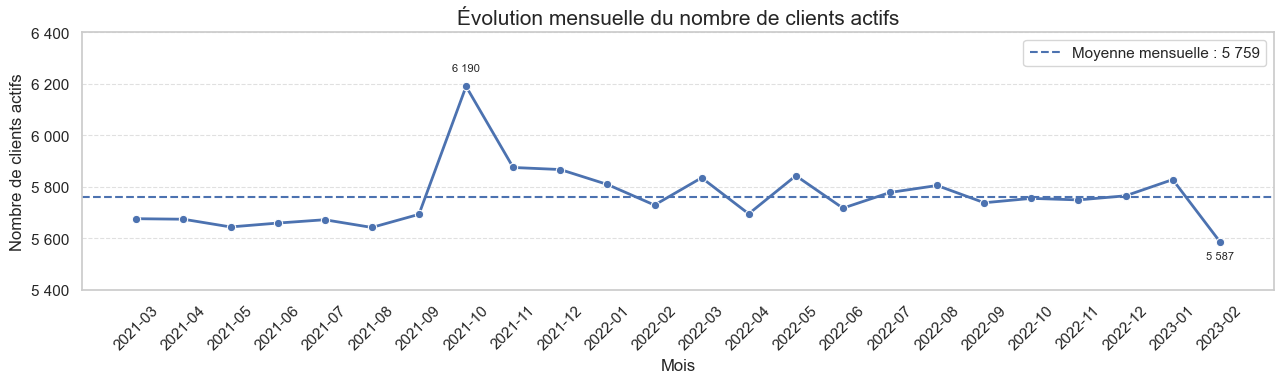

In [37]:
plt.figure(figsize=(13, 4))

ax = sns.lineplot(
    data=clients_mensuels,
    x="mois_annee",
    y="nombre_clients",
    marker="o",
    linewidth=2)

# Points à annoter : maximum et minimum
idx_max = clients_mensuels["nombre_clients"].idxmax()
idx_min = clients_mensuels["nombre_clients"].idxmin()

for idx in [idx_max, idx_min]:
    x = clients_mensuels.loc[idx, "mois_annee"]
    y = clients_mensuels.loc[idx, "nombre_clients"]
    
    # Label au-dessus pour le maximum, légèrement en dessous pour le minimum
    offset = 10 if idx == idx_max else -7
    va = "bottom" if idx == idx_max else "top"
    
    plt.annotate(
        f"{y:,.0f}".replace(",", " "),
        xy=(x, y),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=8    )

# Ligne de moyenne
moyenne_clients = clients_mensuels["nombre_clients"].mean()

plt.axhline(
    moyenne_clients,
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne mensuelle : {moyenne_clients:,.0f}".replace(",", " "))

# Échelle ajustée pour relativiser les variations
plt.ylim(5400, 6400)

# Format axe Y avec intervalles de 200 clients
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(200))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ")))

# Grille : uniquement horizontale
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Évolution mensuelle du nombre de clients actifs", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Nombre de clients actifs")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Le nombre de clients actifs reste relativement stable sur la période, malgré un pic en octobre 2021.  
La baisse observée en février 2023 est cohérente avec la diminution du nombre de transactions et du chiffre d’affaires.

### 6.8 Nombre de produits vendus par mois

Le volume de produits vendus est analysé par mois afin de compléter la lecture de l’activité commerciale, au-delà du chiffre d’affaires et du nombre de transactions.

In [38]:
produits_vendus_mensuels = (
    df_ventes
    .groupby("mois_annee")
    .size()
    .reset_index(name="nombre_produits_vendus"))

produits_vendus_mensuels["mois_annee"] = produits_vendus_mensuels["mois_annee"].astype(str)

display(produits_vendus_mensuels.head())

,mois_annee,nombre_produits_vendus
0,2021-03,28601
1,2021-04,28443
2,2021-05,28285
3,2021-06,26850
4,2021-07,24738


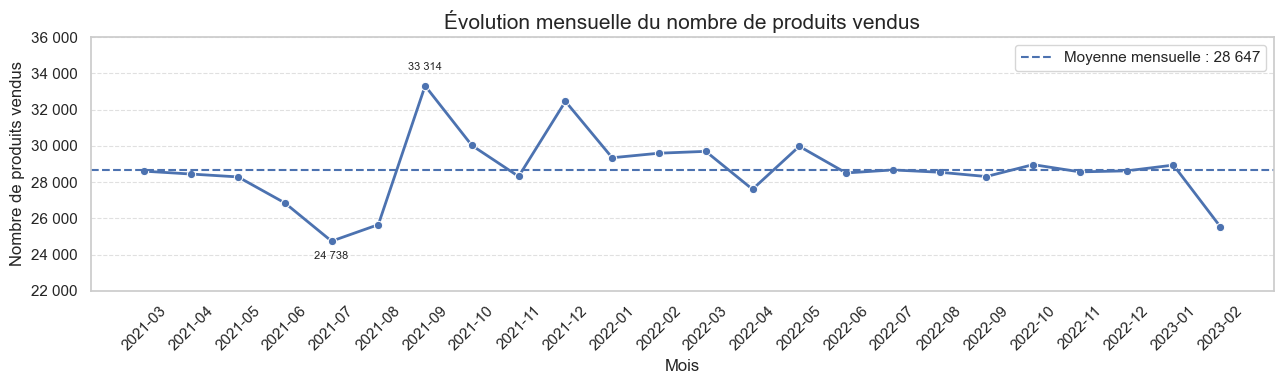

In [39]:
plt.figure(figsize=(13, 4))

ax = sns.lineplot(
    data=produits_vendus_mensuels,
    x="mois_annee",
    y="nombre_produits_vendus",
    marker="o",
    linewidth=2)

# Points à annoter : maximum et minimum
idx_max = produits_vendus_mensuels["nombre_produits_vendus"].idxmax()
idx_min = produits_vendus_mensuels["nombre_produits_vendus"].idxmin()

for idx in [idx_max, idx_min]:
    x = produits_vendus_mensuels.loc[idx, "mois_annee"]
    y = produits_vendus_mensuels.loc[idx, "nombre_produits_vendus"]
    
    # Label au-dessus pour le maximum, légèrement en dessous pour le minimum
    offset = 10 if idx == idx_max else -7
    va = "bottom" if idx == idx_max else "top"
    
    plt.annotate(
        f"{y:,.0f}".replace(",", " "),
        xy=(x, y),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=8)

# Ligne de moyenne
moyenne_produits = produits_vendus_mensuels["nombre_produits_vendus"].mean()

plt.axhline(
    moyenne_produits,
    linestyle="--",
    linewidth=1.5,
    label=f"Moyenne mensuelle : {moyenne_produits:,.0f}".replace(",", " "))

# Échelle ajustée pour relativiser les variations
plt.ylim(22000, 36000)

# Format axe Y avec intervalles de 2 000 produits
plt.gca().yaxis.set_major_locator(mtick.MultipleLocator(2000))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " ")))

# Grille : uniquement horizontale
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Évolution mensuelle du nombre de produits vendus", fontsize=15)
plt.xlabel("Mois")
plt.ylabel("Nombre de produits vendus")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Le volume de produits vendus présente des variations mensuelles, avec un pic en septembre 2021 et un recul en février 2023.  
Il complète l’analyse du chiffre d’affaires et du nombre de transactions.

### 6.9 Top produits par chiffre d’affaires

Les produits générant le plus de chiffre d’affaires sont identifiés afin de repérer les références les plus contributrices à l’activité commerciale.

In [40]:
top_produits_ca = (
    df_ventes
    .groupby("id_prod")
    .agg(
        chiffre_affaires=("chiffre_affaires", "sum"),
        nombre_ventes=("id_prod", "count"),
        prix_unitaire=("price", "first"),
        categorie=("categ", "first")    )
    .reset_index()
    .sort_values(by="chiffre_affaires", ascending=False)
    .head(10))

display(top_produits_ca)

,id_prod,chiffre_affaires,nombre_ventes,prix_unitaire,categorie
3096,2_159,94893.50,650,145.99,2
3070,2_135,69334.95,1005,68.99,2
3045,2_112,65407.76,968,67.57,2
3034,2_102,60736.78,1027,59.14,2
3152,2_209,56971.86,814,69.99,2
2619,1_395,56617.47,1953,28.99,1
2591,1_369,56136.60,2340,23.99,1
3043,2_110,53846.25,865,62.25,2
2607,1_383,53834.43,1857,28.99,1
2641,1_414,53522.18,2246,23.83,1


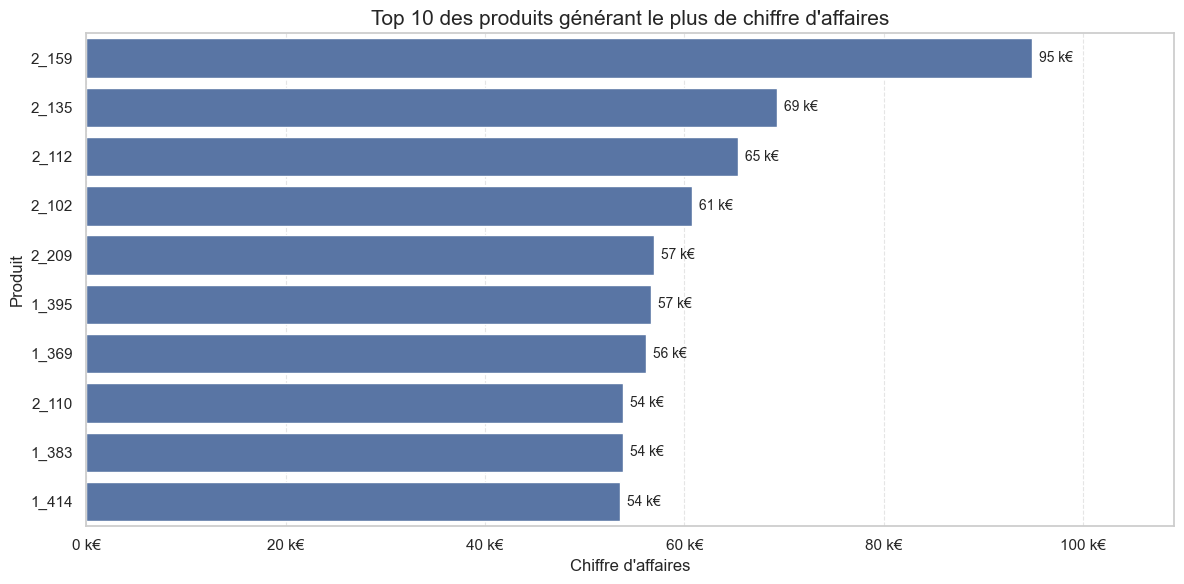

In [41]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_produits_ca,
    x="chiffre_affaires",
    y="id_prod")

# Format axe X en k€
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

# Labels sur les barres
labels = [
    f"{bar.get_width()/1000:.0f} k€"
    for bar in ax.containers[0]]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=5,
    fontsize=10)

# Marge à droite pour éviter que les labels soient coupés
ax.set_xlim(0, top_produits_ca["chiffre_affaires"].max() * 1.15)

# Grille adaptée à un graphique horizontal : uniquement verticale
plt.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
plt.grid(axis="y", visible=False)

plt.title("Top 10 des produits générant le plus de chiffre d'affaires", fontsize=15)
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()

Le top 10 par chiffre d’affaires met en évidence les références les plus contributrices aux revenus.  
Leur performance peut s’expliquer par un volume de ventes élevé, un prix unitaire important, ou une combinaison des deux.

### 6.10 Top produits par volume vendu

Les produits les plus vendus en volume sont identifiés afin de repérer les références les plus fréquemment achetées par les clients.

In [42]:
top_produits_volume = (
    df_ventes
    .groupby("id_prod")
    .agg(
        nombre_ventes=("id_prod", "count"),
        chiffre_affaires=("chiffre_affaires", "sum"),
        prix_unitaire=("price", "first"),
        categorie=("categ", "first")    )
    .reset_index()
    .sort_values(by="nombre_ventes", ascending=False)
    .head(10))

display(top_produits_volume)

,id_prod,nombre_ventes,chiffre_affaires,prix_unitaire,categorie
2591,1_369,2340,56136.60,23.99,1
2644,1_417,2269,47626.31,20.99,1
2641,1_414,2246,53522.18,23.83,1
2733,1_498,2202,51460.74,23.37,1
2653,1_425,2163,36749.37,16.99,1
2629,1_403,2040,36699.60,17.99,1
2640,1_413,2036,36627.64,17.99,1
2639,1_412,2014,33533.10,16.65,1
2632,1_406,2003,49694.43,24.81,1
2633,1_407,2001,31995.99,15.99,1


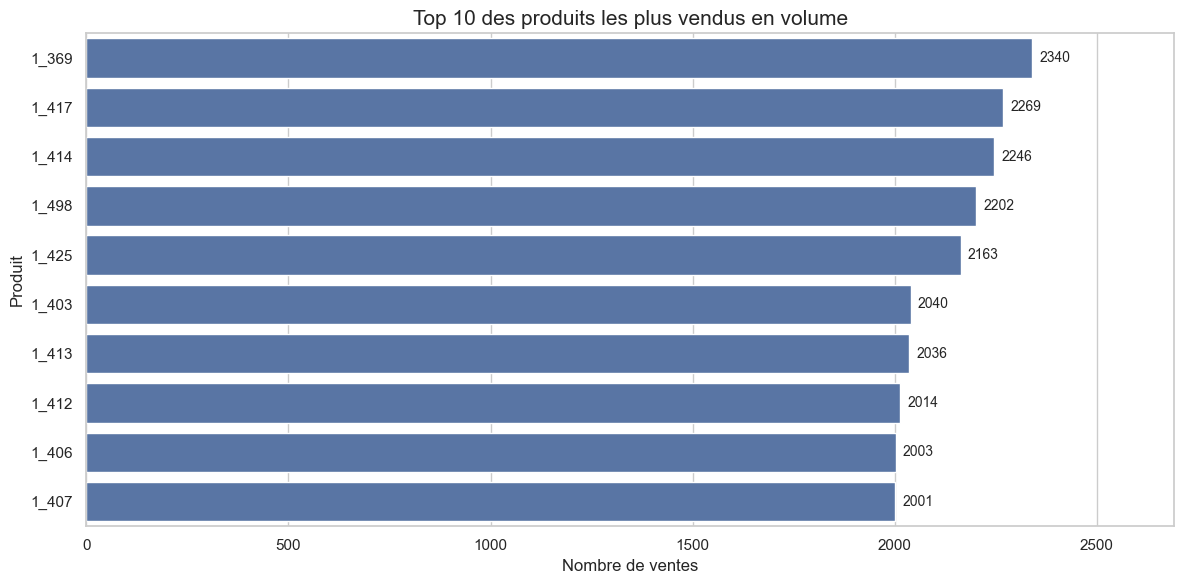

In [43]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_produits_volume,
    x="nombre_ventes",
    y="id_prod")

labels = [
    f"{bar.get_width():.0f}"
    for bar in ax.containers[0]]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=5,
    fontsize=10)

ax.set_xlim(0, top_produits_volume["nombre_ventes"].max() * 1.15)

plt.title("Top 10 des produits les plus vendus en volume", fontsize=15)
plt.xlabel("Nombre de ventes")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()

Le classement par volume identifie les produits les plus fréquemment achetés.  
Il complète l’analyse du chiffre d’affaires en distinguant les références à fort volume des références à forte contribution financière.

### 6.11 Comparaison entre les tops produits en chiffre d’affaires et en volume

Les classements par chiffre d’affaires et par volume vendu sont comparés afin d’identifier si les références les plus vendues sont également celles qui génèrent le plus de revenus.

In [44]:
produits_top_ca = set(top_produits_ca["id_prod"])
produits_top_volume = set(top_produits_volume["id_prod"])

produits_communs = produits_top_ca.intersection(produits_top_volume)

print("Nombre de produits communs entre les deux tops :", len(produits_communs))
print("Produits communs :", produits_communs)

Nombre de produits communs entre les deux tops : 2
Produits communs : {'1_414', '1_369'}


In [45]:
comparaison_tops = (
    df_ventes
    .groupby("id_prod")
    .agg(
        chiffre_affaires=("chiffre_affaires", "sum"),
        nombre_ventes=("id_prod", "count"),
        prix_unitaire=("price", "first"),
        categorie=("categ", "first")    )
    .reset_index())

comparaison_tops["top_ca"] = comparaison_tops["id_prod"].isin(top_produits_ca["id_prod"])
comparaison_tops["top_volume"] = comparaison_tops["id_prod"].isin(top_produits_volume["id_prod"])

comparaison_tops_filtre = comparaison_tops[
    (comparaison_tops["top_ca"]) | (comparaison_tops["top_volume"])
].sort_values(by="chiffre_affaires", ascending=False)

display(comparaison_tops_filtre)

,id_prod,chiffre_affaires,nombre_ventes,prix_unitaire,categorie,top_ca,top_volume
3096,2_159,94893.50,650,145.99,2,True,False
3070,2_135,69334.95,1005,68.99,2,True,False
3045,2_112,65407.76,968,67.57,2,True,False
3034,2_102,60736.78,1027,59.14,2,True,False
3152,2_209,56971.86,814,69.99,2,True,False
2619,1_395,56617.47,1953,28.99,1,True,False
2591,1_369,56136.60,2340,23.99,1,True,True
3043,2_110,53846.25,865,62.25,2,True,False
2607,1_383,53834.43,1857,28.99,1,True,False
2641,1_414,53522.18,2246,23.83,1,True,True


In [46]:
prix_moyen_top_ca = top_produits_ca["prix_unitaire"].mean()
prix_moyen_top_volume = top_produits_volume["prix_unitaire"].mean()

print(f"Prix moyen des produits du top CA : {prix_moyen_top_ca:.2f} €")
print(f"Prix moyen des produits du top volume : {prix_moyen_top_volume:.2f} €")

Prix moyen des produits du top CA : 57.97 €
Prix moyen des produits du top volume : 20.26 €


Les produits du top chiffre d’affaires présentent un prix moyen nettement supérieur à ceux du top volume : 57,97 € contre 20,26 €.  
La contribution au chiffre d’affaires dépend donc fortement du prix unitaire, et pas uniquement du nombre de ventes.

### 6.12 Flop produits

Les produits les moins contributeurs sont analysés afin d’identifier les références générant le plus faible chiffre d’affaires.  
Un faible chiffre d’affaires peut s’expliquer par un faible volume de ventes, un prix unitaire bas ou un positionnement de niche.

In [47]:
# Construction du flop produits avec CA et volume vendu
flop_produits = (
    df_ventes
    .groupby("id_prod")
    .agg(
        chiffre_affaires=("price", "sum"),
        volume_vendu=("id_prod", "count")    )
    .reset_index()
    .sort_values("chiffre_affaires", ascending=True)
    .head(10))

# Affichage du tableau
display(flop_produits)

,id_prod,chiffre_affaires,volume_vendu
595,0_1539,0.99,1
313,0_1284,1.38,1
719,0_1653,1.98,2
1784,0_541,1.99,1
665,0_1601,1.99,1
2079,0_807,1.99,1
802,0_1728,2.27,1
549,0_1498,2.48,1
2179,0_898,2.54,2
925,0_1840,2.56,2


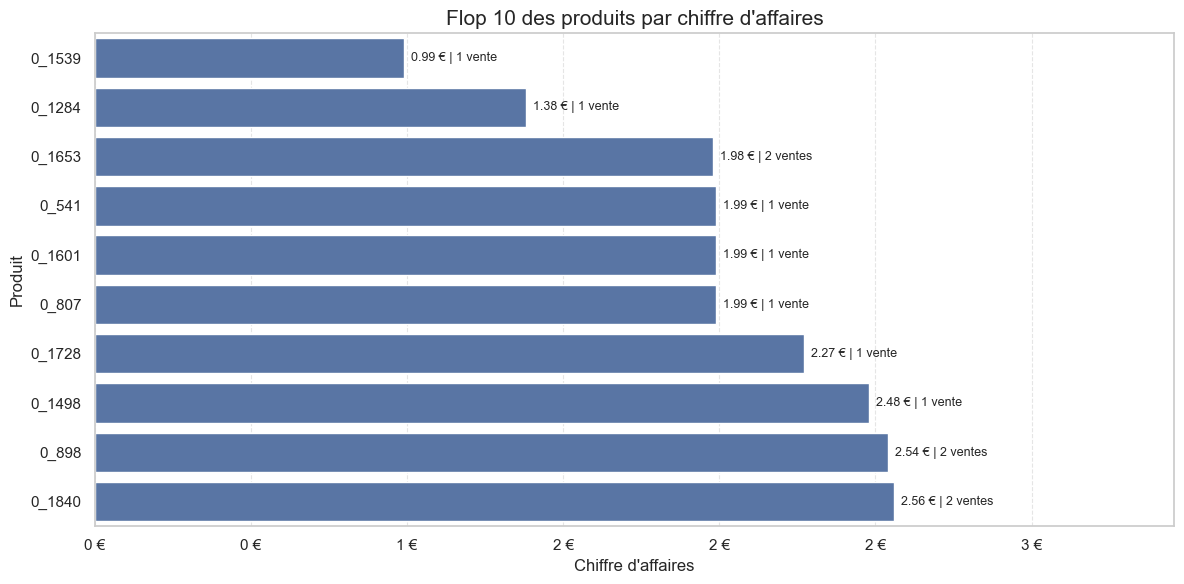

In [48]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=flop_produits,
    x="chiffre_affaires",
    y="id_prod")

# Format axe X en €
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:.0f} €"))

# Labels combinant CA et volume vendu
labels = [
    f"{ca:.2f} € | {vol} vente" if vol == 1 else f"{ca:.2f} € | {vol} ventes"
    for ca, vol in zip(flop_produits["chiffre_affaires"], flop_produits["volume_vendu"])]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=5,
    fontsize=9)

# Marge à droite pour les labels
ax.set_xlim(0, flop_produits["chiffre_affaires"].max() * 1.35)

# Grille adaptée à un graphique horizontal
plt.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.5)
plt.grid(axis="y", visible=False)

plt.title("Flop 10 des produits par chiffre d'affaires", fontsize=15)
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()

Les flops identifiés appartiennent tous à la catégorie 0.  
Cela ne remet pas en cause la performance globale de cette catégorie, qui reste l’une des principales contributrices au chiffre d’affaires.

### 6.13 Synthèse de l’analyse des ventes

L’analyse des ventes met en évidence une activité en ligne globalement stable, avec des variations mensuelles principalement liées au volume de transactions.

La catégorie 1 est la plus contributrice au chiffre d’affaires, suivie de près par la catégorie 0. La catégorie 2 présente une contribution plus limitée.

L’analyse des produits montre que les références générant le plus de chiffre d’affaires ne sont pas nécessairement les plus vendues en volume. Cette différence s’explique notamment par le prix unitaire plus élevé des produits du top chiffre d’affaires.

Enfin, les flops doivent être interprétés au niveau des références produits, sans conclure à une mauvaise performance globale de leur catégorie.

Après l’analyse globale des ventes, l’étude se concentre maintenant sur les clients.  
Cette seconde partie vise à mieux comprendre la structure du chiffre d’affaires par client, le niveau de concentration des ventes et certains comportements d’achat.

Elle prépare également les analyses statistiques demandées par l’équipe BI, qui portent sur les liens entre le profil des clients — notamment l’âge et le genre — et leurs comportements d’achat.

## 7. Analyse des clients

Cette section analyse les clients à partir de leurs achats en ligne.  
L’objectif est d’étudier leur contribution au chiffre d’affaires, d’identifier les profils les plus contributeurs et de préparer les analyses statistiques.

### 7.1 Construction d’une base client

Une base client est construite afin de synthétiser le comportement d’achat de chaque client : profil, chiffre d’affaires total, nombre de transactions, produits achetés et panier moyen.

In [49]:
base_clients = (
    df_ventes
    .groupby("client_id")
    .agg(
        sex=("sex", "first"),
        birth=("birth", "first"),
        age=("age", "first"),
        chiffre_affaires_total=("chiffre_affaires", "sum"),
        nombre_transactions=("session_id", "nunique"),
        nombre_produits_achetes=("id_prod", "count")    )
    .reset_index())

base_clients["panier_moyen"] = (
    base_clients["chiffre_affaires_total"] 
    / base_clients["nombre_transactions"])

display(base_clients.head())

,client_id,sex,birth,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen
0,c_1,m,1955,66,629.02,34,43,18.50
1,c_10,m,1956,65,1353.60,34,58,39.81
2,c_100,m,1992,29,254.85,5,8,50.97
3,c_1000,f,1966,55,2291.88,94,126,24.38
4,c_1001,m,1982,39,1823.85,47,103,38.81


In [50]:
print(f"La base client contient {base_clients.shape[0]} clients et {base_clients.shape[1]} colonnes.")

La base client contient 8600 clients et 8 colonnes.


In [51]:
nb_clients_customers = customers["client_id"].nunique()
nb_clients_ventes = df_ventes["client_id"].nunique()

print("Nombre de clients dans customers :", nb_clients_customers)
print("Nombre de clients avec au moins une transaction :", nb_clients_ventes)
print("Clients sans transaction :", nb_clients_customers - nb_clients_ventes)

Nombre de clients dans customers : 8621
Nombre de clients avec au moins une transaction : 8600
Clients sans transaction : 21


In [52]:
clients_sans_transaction = customers[
    ~customers["client_id"].isin(df_ventes["client_id"])]

display(clients_sans_transaction)

,client_id,sex,birth
801,c_8253,f,2001
2483,c_3789,f,1997
2734,c_4406,f,1998
2768,c_2706,f,1967
2850,c_3443,m,1959
3178,c_4447,m,1956
3189,c_3017,f,1992
3333,c_4086,f,1992
3720,c_6930,m,2004
3820,c_4358,m,1999


La base client ne conserve que les clients ayant réalisé au moins une transaction.  
L’écart avec la table `customers` correspond aux clients référencés sans achat enregistré sur la période.

### 7.2 Chiffre d’affaires par client

Cette section analyse la contribution des clients au chiffre d’affaires afin de déterminer si l’activité repose sur une base large ou sur quelques clients très contributeurs.

In [53]:
#  Statistiques descriptives du chiffre d’affaires par client
base_clients["chiffre_affaires_total"].describe()

count     8600.00
mean      1398.57
std       5202.77
min          6.31
25%        562.73
50%       1045.70
75%       1797.72
max     326039.89
Name: chiffre_affaires_total, dtype: float64

In [54]:
# Top clients 
top_clients_ca = (
    base_clients
    .sort_values(by="chiffre_affaires_total", ascending=False)
    .head(10))

display(top_clients_ca)

,client_id,sex,birth,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen
677,c_1609,m,1980,41,326039.89,10997,25586,29.65
4388,c_4958,m,1999,22,290227.03,3851,5222,75.36
6337,c_6714,f,1968,53,153918.60,2620,9199,58.75
2724,c_3454,m,1969,52,114110.57,5571,6793,20.48
634,c_1570,f,1979,42,5285.82,159,370,33.24
2513,c_3263,f,1985,36,5276.87,143,403,36.90
1268,c_2140,f,1977,44,5260.18,147,405,35.78
2108,c_2899,f,1994,27,5214.05,69,105,75.57
7006,c_7319,f,1974,47,5155.77,145,371,35.56
7715,c_7959,f,1974,47,5135.75,148,372,34.70


### 7.3 Répartition et concentration du chiffre d’affaires

Cette section mesure la part du chiffre d’affaires générée par les principaux clients.  
Elle permet d’évaluer si l’activité est fortement concentrée ou si elle reste répartie sur une base client plus large.

In [55]:
# Classement des clients par chiffre d'affaires décroissant
clients_classes = base_clients.sort_values(
    by="chiffre_affaires_total",
    ascending=False).reset_index(drop=True)

ca_total_clients = clients_classes["chiffre_affaires_total"].sum()

# Calcul des contributions de différents groupes de clients
concentration_clients = pd.DataFrame({
    "groupe_clients": [
        "Top 1 client",
        "Top 5 clients",
        "Top 10 clients",
        "Top 1 % clients",
        "Top 5 % clients"],
    "nombre_clients": [
        1,
        5,
        10,
        int(len(clients_classes) * 0.01),
        int(len(clients_classes) * 0.05)]})

concentration_clients["chiffre_affaires"] = concentration_clients["nombre_clients"].apply(
    lambda n: clients_classes.head(n)["chiffre_affaires_total"].sum())

concentration_clients["part_ca"] = (
    concentration_clients["chiffre_affaires"] / ca_total_clients * 100)

display(concentration_clients)

,groupe_clients,nombre_clients,chiffre_affaires,part_ca
0,Top 1 client,1,326039.89,2.71
1,Top 5 clients,5,889581.91,7.40
2,Top 10 clients,10,915624.53,7.61
3,Top 1 % clients,86,1266118.82,10.53
4,Top 5 % clients,430,2529402.05,21.03


In [56]:
top_clients_detail = (
    base_clients
    .sort_values(by="chiffre_affaires_total", ascending=False)
    .head(10)
            [[
            "client_id",
            "sex",
            "age",
            "chiffre_affaires_total",
            "nombre_transactions",
            "nombre_produits_achetes",
            "panier_moyen"]])

display(top_clients_detail)

,client_id,sex,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen
677,c_1609,m,41,326039.89,10997,25586,29.65
4388,c_4958,m,22,290227.03,3851,5222,75.36
6337,c_6714,f,53,153918.60,2620,9199,58.75
2724,c_3454,m,52,114110.57,5571,6793,20.48
634,c_1570,f,42,5285.82,159,370,33.24
2513,c_3263,f,36,5276.87,143,403,36.90
1268,c_2140,f,44,5260.18,147,405,35.78
2108,c_2899,f,27,5214.05,69,105,75.57
7006,c_7319,f,47,5155.77,145,371,35.56
7715,c_7959,f,47,5135.75,148,372,34.70


Cette analyse met en évidence le poids des principaux clients dans le chiffre d’affaires total.  
Le premier client représente 2,71 % du chiffre d’affaires, tandis que les 5 % de clients les plus contributeurs en représentent 21,03 %.

Le détail des principaux clients montre que ces profils se distinguent par des volumes d’achat très élevés, avec un nombre important de transactions et de produits achetés. Certains présentent également un panier moyen nettement supérieur aux autres.

Aucune variable ne permet d’identifier directement les clients BtoB dans les données disponibles.  
Ces profils très contributeurs peuvent donc être considérés comme des clients à investiguer, sans être qualifiés formellement de BtoB.

In [57]:
top_clients_ids = top_clients_detail["client_id"]

categories_top_clients = pd.crosstab(
    df_ventes[df_ventes["client_id"].isin(top_clients_ids)]["client_id"],
    df_ventes[df_ventes["client_id"].isin(top_clients_ids)]["categ"],
    normalize="index") * 100

display(categories_top_clients.round(2))

categ,0,1,2
client_id,,,
c_1570,70.27,29.46,0.27
c_1609,78.82,21.14,0.04
c_2140,76.54,23.21,0.25
c_2899,2.86,39.05,58.10
c_3263,77.92,22.08,0.00
c_3454,39.70,60.03,0.26
c_4958,0.08,36.67,63.25
c_6714,57.72,38.98,3.29
c_7319,73.85,25.88,0.27


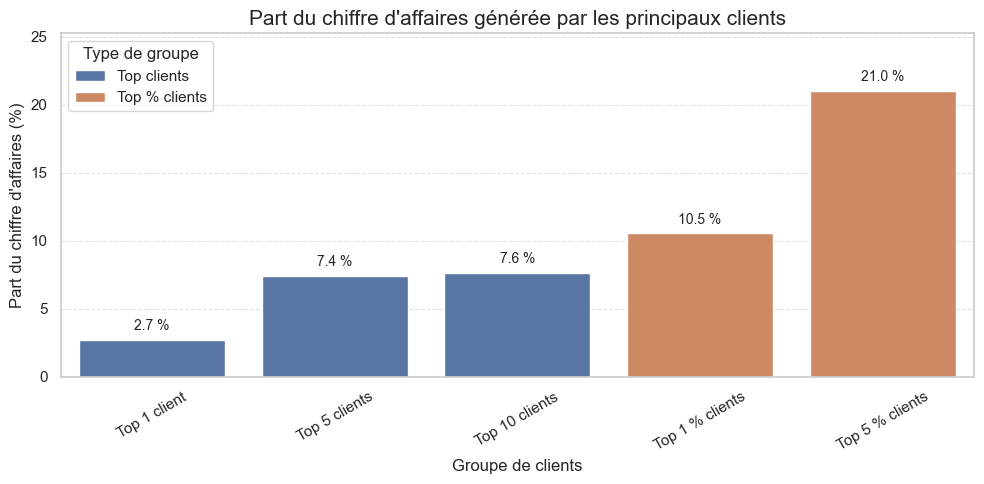

In [58]:
# Création d'une variable pour distinguer les types de groupes
concentration_clients_plot = concentration_clients.copy()

concentration_clients_plot["type_groupe"] = concentration_clients_plot["groupe_clients"].apply(
    lambda x: "Top clients" if "%" not in x else "Top % clients")

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=concentration_clients_plot,
    x="groupe_clients",
    y="part_ca",
    hue="type_groupe",
    dodge=False)

# Labels sur toutes les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1f} %" if x > 0 else "",
        padding=5,
        fontsize=10    )

# Marge en haut pour les labels
ax.set_ylim(0, concentration_clients_plot["part_ca"].max() * 1.20)

# Grille horizontale uniquement
plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.title("Part du chiffre d'affaires générée par les principaux clients", fontsize=15)
plt.xlabel("Groupe de clients")
plt.ylabel("Part du chiffre d'affaires (%)")
plt.xticks(rotation=30)

plt.legend(title="Type de groupe")

plt.tight_layout()
plt.show()

Les principaux clients pèsent de manière notable dans le chiffre d’affaires : le top 1 % représente 10,5 % du total, et le top 5 % en représente 21,0 %.  
La concentration existe donc, mais reste maîtrisée : l’activité ne dépend pas uniquement de quelques clients isolés.

L’étude détaillée des principaux clients montre que les profils les plus contributeurs se distinguent surtout par un volume élevé de transactions et de produits achetés.  
Ces résultats préparent l’analyse plus globale de la concentration du chiffre d’affaires, approfondie avec la courbe de Lorenz.

### 7.4 Courbe de Lorenz

La courbe de Lorenz permet de visualiser la concentration du chiffre d’affaires entre les clients.  
Elle compare la répartition observée à une situation d’égalité parfaite.

In [59]:
# Tri des clients par chiffre d'affaires croissant
clients_lorenz = base_clients.sort_values(
    by="chiffre_affaires_total").reset_index(drop=True)

# Calcul des parts cumulées de clients et de chiffre d'affaires
clients_lorenz["part_clients_cumulee"] = (
    np.arange(1, len(clients_lorenz) + 1) / len(clients_lorenz))

clients_lorenz["part_ca_cumulee"] = (
    clients_lorenz["chiffre_affaires_total"].cumsum()
    / clients_lorenz["chiffre_affaires_total"].sum())

# Ajout du point de départ (0,0)
lorenz_x = np.insert(clients_lorenz["part_clients_cumulee"].values, 0, 0)
lorenz_y = np.insert(clients_lorenz["part_ca_cumulee"].values, 0, 0)

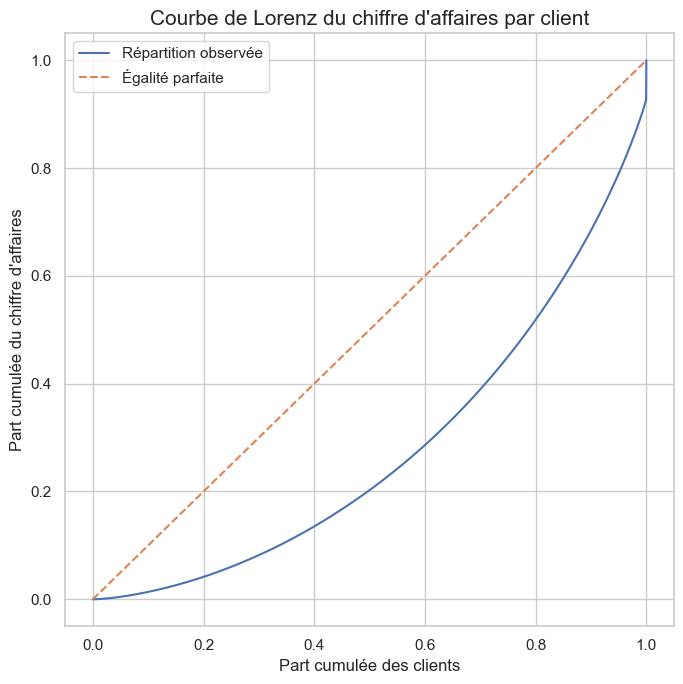

In [60]:
plt.figure(figsize=(7, 7))

plt.plot(
    lorenz_x,
    lorenz_y,
    label="Répartition observée")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Égalité parfaite")

plt.title("Courbe de Lorenz du chiffre d'affaires par client", fontsize=15)
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du chiffre d'affaires")
plt.legend()
plt.tight_layout()
plt.show()

La courbe de Lorenz met en évidence une concentration du chiffre d’affaires entre les clients.  
Cette lecture confirme que certains clients contribuent davantage à l’activité, sans traduire une dépendance excessive à quelques profils isolés.

In [61]:
# Calcul de la part du chiffre d'affaires générée par les clients les moins contributeurs

# Tri des clients par chiffre d'affaires croissant
ca_clients_sorted = base_clients["chiffre_affaires_total"].sort_values().reset_index(drop=True)

# Part cumulée du chiffre d'affaires
part_ca_cumulee = ca_clients_sorted.cumsum() / ca_clients_sorted.sum()

# Part cumulée des clients
part_clients_cumulee = pd.Series(
    (ca_clients_sorted.index + 1) / len(ca_clients_sorted))

# Fonction pour récupérer la part de CA générée par les X % de clients les moins contributeurs
def part_ca_pourcentage_clients(pourcentage_clients):
    idx = (part_clients_cumulee - pourcentage_clients).abs().idxmin()
    return part_ca_cumulee.iloc[idx] * 100

# Calcul pour 80 %, 90 % et 95 % des clients les moins contributeurs
part_80 = part_ca_pourcentage_clients(0.80)
part_90 = part_ca_pourcentage_clients(0.90)
part_95 = part_ca_pourcentage_clients(0.95)

# Affichage des résultats
parts_clients_lorenz = pd.DataFrame({
    "clients_les_moins_contributeurs": [
        "80 % des clients",
        "90 % des clients",
        "95 % des clients"],
    "part_ca": [
        part_80,
        part_90,
        part_95]})

parts_clients_lorenz["part_ca"] = parts_clients_lorenz["part_ca"].round(1)

display(parts_clients_lorenz)

,clients_les_moins_contributeurs,part_ca
0,80 % des clients,51.90
1,90 % des clients,68.40
2,95 % des clients,79.00


In [62]:
# Déduction de la part de CA générée par les clients les plus contributeurs

repartition_top_clients = pd.DataFrame({
    "groupe_clients": [
        "Top 20 % clients",
        "Top 10 % clients",
        "Top 5 % clients"],
    "part_ca": [
        100 - part_80,
        100 - part_90,
        100 - part_95]})

repartition_top_clients["part_ca"] = repartition_top_clients["part_ca"].round(1)

display(repartition_top_clients)

,groupe_clients,part_ca
0,Top 20 % clients,48.10
1,Top 10 % clients,31.60
2,Top 5 % clients,21.00


In [63]:
for seuil in [0.80, 0.90, 0.95]:
    ligne = clients_lorenz[
        clients_lorenz["part_clients_cumulee"] >= seuil
    ].iloc[0]
    
    part_clients_top = 1 - seuil
    part_ca_top = 1 - ligne["part_ca_cumulee"]
    
    print(
        f"Les {part_clients_top:.0%} des clients les plus contributeurs génèrent "
        f"{part_ca_top:.1%} du chiffre d'affaires."    )

Les 20% des clients les plus contributeurs génèrent 48.1% du chiffre d'affaires.
Les 10% des clients les plus contributeurs génèrent 31.6% du chiffre d'affaires.
Les 5% des clients les plus contributeurs génèrent 21.0% du chiffre d'affaires.


Les résultats issus de la courbe de Lorenz permettent de quantifier la concentration du chiffre d’affaires.  
Les 20 % de clients les plus contributeurs génèrent 48,1 % du chiffre d’affaires, tandis que les 5 % les plus contributeurs en génèrent 21,0 %.

La contribution des principaux clients est donc significative, mais le chiffre d’affaires reste réparti sur une base client relativement large.

### 7.5 Identification des clients atypiques

Certains clients présentent un chiffre d’affaires nettement supérieur au reste de la base.  
Cette étape vise à identifier ces profils atypiques afin de mesurer leur poids dans l’activité et de mieux comprendre leur comportement d’achat.

In [64]:
# Calcul des quartiles et de l'écart interquartile
q1 = base_clients["chiffre_affaires_total"].quantile(0.25)
q3 = base_clients["chiffre_affaires_total"].quantile(0.75)
iqr = q3 - q1

# Seuil d'identification des clients atypiques
seuil_atypique = q3 + 1.5 * iqr

print(f"Q1 : {q1:.2f} €")
print(f"Q3 : {q3:.2f} €")
print(f"IQR : {iqr:.2f} €")
print(f"Seuil clients atypiques : {seuil_atypique:.2f} €")

Q1 : 562.73 €
Q3 : 1797.72 €
IQR : 1234.99 €
Seuil clients atypiques : 3650.20 €


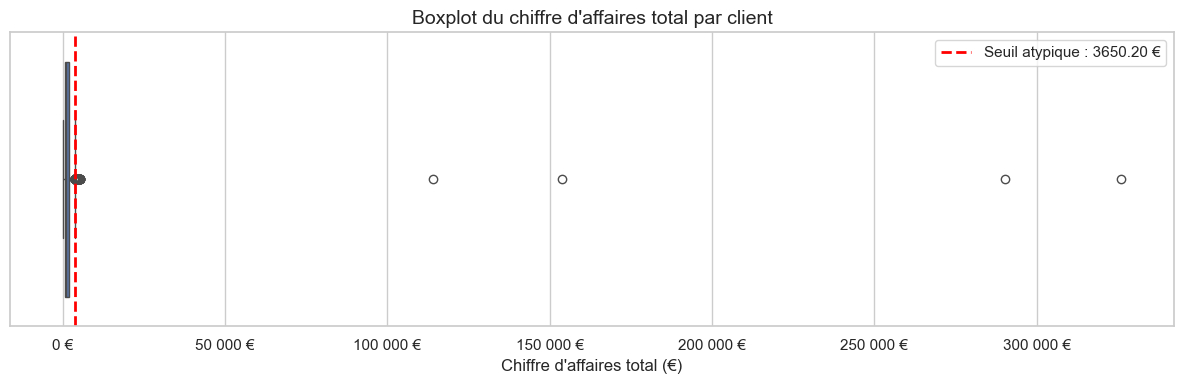

In [65]:
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    x=base_clients["chiffre_affaires_total"])

# Ligne du seuil atypique
plt.axvline(
    seuil_atypique,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Seuil atypique : {seuil_atypique:.2f} €")

# Format axe X
plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f} €".replace(",", " ")))

plt.title("Boxplot du chiffre d'affaires total par client", fontsize=14)
plt.xlabel("Chiffre d'affaires total (€)")
plt.legend()
plt.tight_layout()
plt.show()

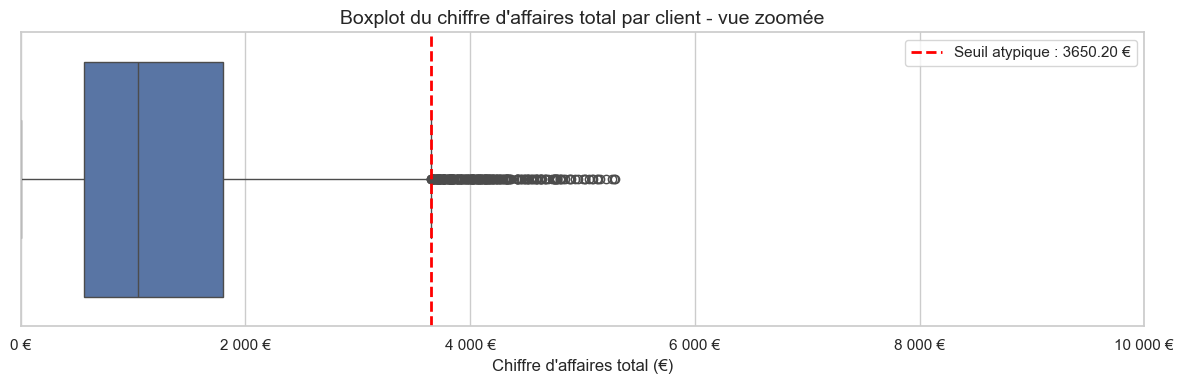

In [66]:
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    x=base_clients["chiffre_affaires_total"])

plt.axvline(
    seuil_atypique,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Seuil atypique : {seuil_atypique:.2f} €")

plt.xlim(0, 10000)

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f} €".replace(",", " ")))

plt.title("Boxplot du chiffre d'affaires total par client - vue zoomée", fontsize=14)
plt.xlabel("Chiffre d'affaires total (€)")
plt.legend()
plt.tight_layout()
plt.show()

Le boxplot zoomé limite l’axe du chiffre d’affaires à 10 000 € afin de mieux visualiser la zone où se situe la majorité des clients.  
Ce choix est uniquement graphique : le calcul du seuil atypique reste effectué sur l’ensemble de la base.

La ligne rouge correspond au seuil calculé avec la méthode de l’écart interquartile : Q3 + 1,5 × IQR.  
Dans cette analyse, ce seuil est fixé à 3 650,20 €. Les clients situés au-delà sont considérés comme atypiques.

In [67]:
clients_atypiques = (
    base_clients[
        base_clients["chiffre_affaires_total"] > seuil_atypique
    ]
    .sort_values(by="chiffre_affaires_total", ascending=False))

display(clients_atypiques.head(20))

print(f"Nombre de clients atypiques : {clients_atypiques.shape[0]}")
print(
    f"Part des clients atypiques dans la base : "
    f"{clients_atypiques.shape[0] / base_clients.shape[0] * 100:.2f} %")

,client_id,sex,birth,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen
677,c_1609,m,1980,41,326039.89,10997,25586,29.65
4388,c_4958,m,1999,22,290227.03,3851,5222,75.36
6337,c_6714,f,1968,53,153918.60,2620,9199,58.75
2724,c_3454,m,1969,52,114110.57,5571,6793,20.48
634,c_1570,f,1979,42,5285.82,159,370,33.24
2513,c_3263,f,1985,36,5276.87,143,403,36.90
1268,c_2140,f,1977,44,5260.18,147,405,35.78
2108,c_2899,f,1994,27,5214.05,69,105,75.57
7006,c_7319,f,1974,47,5155.77,145,371,35.56
7715,c_7959,f,1974,47,5135.75,148,372,34.70


Nombre de clients atypiques : 251
Part des clients atypiques dans la base : 2.92 %


In [68]:
ca_clients_atypiques = clients_atypiques["chiffre_affaires_total"].sum()
ca_total = base_clients["chiffre_affaires_total"].sum()

part_ca_clients_atypiques = ca_clients_atypiques / ca_total * 100

print(f"Chiffre d'affaires des clients atypiques : {ca_clients_atypiques:,.2f} €")
print(f"Part du chiffre d'affaires total : {part_ca_clients_atypiques:.2f} %")

Chiffre d'affaires des clients atypiques : 1,913,513.08 €
Part du chiffre d'affaires total : 15.91 %


La méthode de l’écart interquartile permet d’identifier 251 clients atypiques, soit 2,92 % de la base.  
Ces clients génèrent 15,91 % du chiffre d’affaires total, ce qui montre qu’un petit groupe contribue de manière significative à l’activité.

Certains profils présentent des montants particulièrement élevés et doivent être interprétés avec prudence.  
Ils peuvent correspondre à des comportements d’achat exceptionnels ou à des usages spécifiques, sans pouvoir être qualifiés formellement de clients BtoB avec les données disponibles.

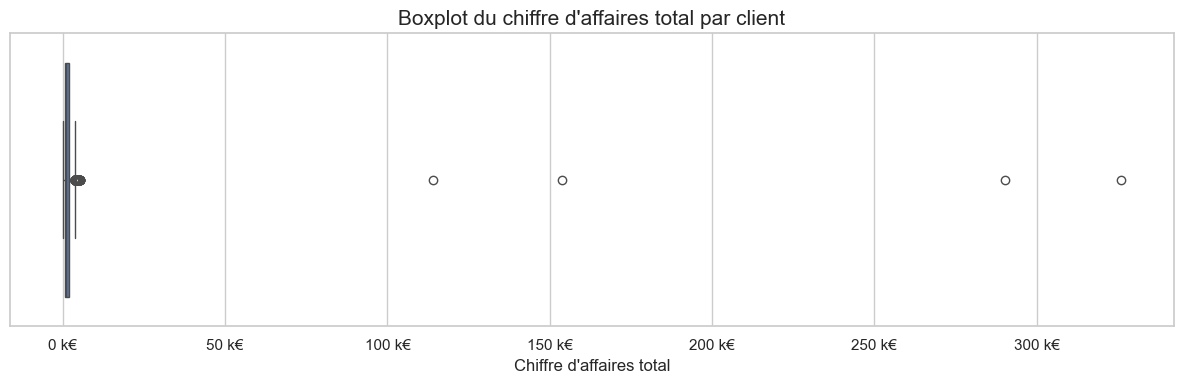

In [69]:
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    data=base_clients,
    x="chiffre_affaires_total")

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

plt.title("Boxplot du chiffre d'affaires total par client", fontsize=15)
plt.xlabel("Chiffre d'affaires total")
plt.tight_layout()
plt.show()

Le boxplot complet met en évidence une forte asymétrie du chiffre d’affaires par client.  
Quelques clients présentent des montants très élevés, ce qui étire l’échelle du graphique et rend la distribution principale difficile à lire.

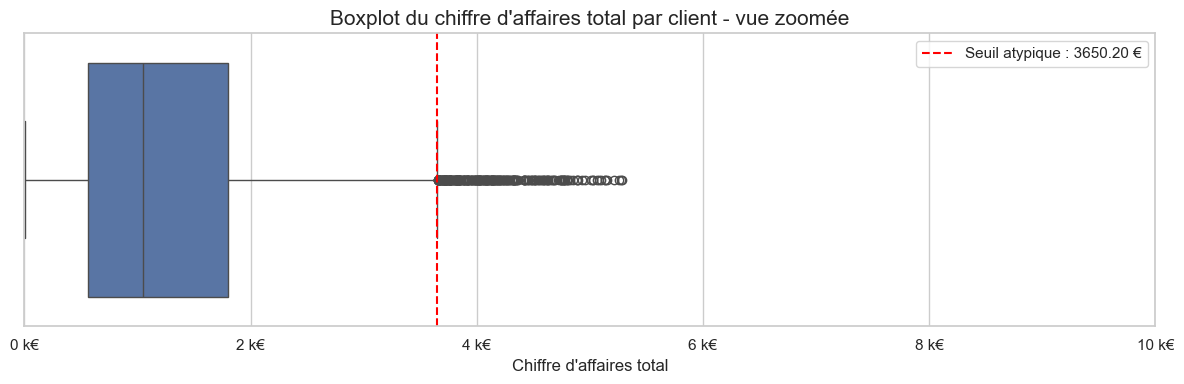

In [70]:
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    data=base_clients,
    x="chiffre_affaires_total")

# Seuil atypique déjà calculé avec la méthode IQR
plt.axvline(
    seuil_atypique,
    color="red",
    linestyle="--",
    label=f"Seuil atypique : {seuil_atypique:.2f} €")

ax.set_xlim(0, 10000)

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f} k€"))

plt.title("Boxplot du chiffre d'affaires total par client - vue zoomée", fontsize=15)
plt.xlabel("Chiffre d'affaires total")
plt.legend()
plt.tight_layout()
plt.show()

La vue zoomée limite l’axe du chiffre d’affaires à 10 000 € afin de mieux visualiser la zone où se situe la majorité des clients.  
Ce choix est uniquement graphique : le seuil atypique reste calculé sur l’ensemble de la base.

La ligne rouge indique le seuil d’identification des clients atypiques, fixé à 3 650,20 € selon la méthode de l’écart interquartile.

## 8. Analyses statistiques du comportement client

Cette section répond aux demandes de Julie concernant les relations entre le profil des clients et leurs comportements d’achat.

Les analyses portent notamment sur le genre, l’âge, le montant total des achats, la fréquence d’achat, le panier moyen et les catégories de produits achetées.


### 8.1 Préparation des variables pour les analyses statistiques

Les analyses statistiques s’appuient sur deux bases complémentaires :

- `base_clients`, avec une ligne par client, pour analyser l’âge, le montant total des achats, la fréquence d’achat et le panier moyen ;
- `df_ventes`, avec une ligne par produit acheté, pour analyser les catégories de produits.

In [71]:
# Base client pour les analyses individuelles
variables_clients = base_clients[
    [
        "client_id",
        "sex",
        "birth",
        "age",
        "chiffre_affaires_total",
        "nombre_transactions",
        "nombre_produits_achetes",
        "panier_moyen"]].copy()

display(variables_clients.head())

,client_id,sex,birth,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen
0,c_1,m,1955,66,629.02,34,43,18.50
1,c_10,m,1956,65,1353.60,34,58,39.81
2,c_100,m,1992,29,254.85,5,8,50.97
3,c_1000,f,1966,55,2291.88,94,126,24.38
4,c_1001,m,1982,39,1823.85,47,103,38.81


In [72]:
variables_clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   client_id                8600 non-null   object 
 1   sex                      8600 non-null   object 
 2   birth                    8600 non-null   int64  
 3   age                      8600 non-null   int64  
 4   chiffre_affaires_total   8600 non-null   float64
 5   nombre_transactions      8600 non-null   int64  
 6   nombre_produits_achetes  8600 non-null   int64  
 7   panier_moyen             8600 non-null   float64
dtypes: float64(2), int64(4), object(2)
memory usage: 537.6+ KB


In [73]:
variables_clients.isna().sum()

client_id                  0
sex                        0
birth                      0
age                        0
chiffre_affaires_total     0
nombre_transactions        0
nombre_produits_achetes    0
panier_moyen               0
dtype: int64

La base client utilisée pour les analyses statistiques ne présente pas de valeurs manquantes sur les variables sélectionnées.

### 8.2 Genre des clients et catégories achetées

Cette analyse étudie le lien entre le genre des clients et les catégories de produits achetées.

Les deux variables étant catégorielles, un test du Chi-2 est utilisé pour évaluer l’existence d’une association, puis le V de Cramer permet d’en mesurer l’intensité.

In [74]:
table_genre_categorie = pd.crosstab(
    df_ventes["sex"],
    df_ventes["categ"])

display(table_genre_categorie)

categ,0,1,2
sex,,,
f,206103,119307,17283
m,209356,116285,19200


In [75]:
table_genre_categorie_pct = pd.crosstab(
    df_ventes["sex"],
    df_ventes["categ"],
    normalize="index") * 100

display(table_genre_categorie_pct.round(2))

categ,0,1,2
sex,,,
f,60.14,34.81,5.04
m,60.71,33.72,5.57


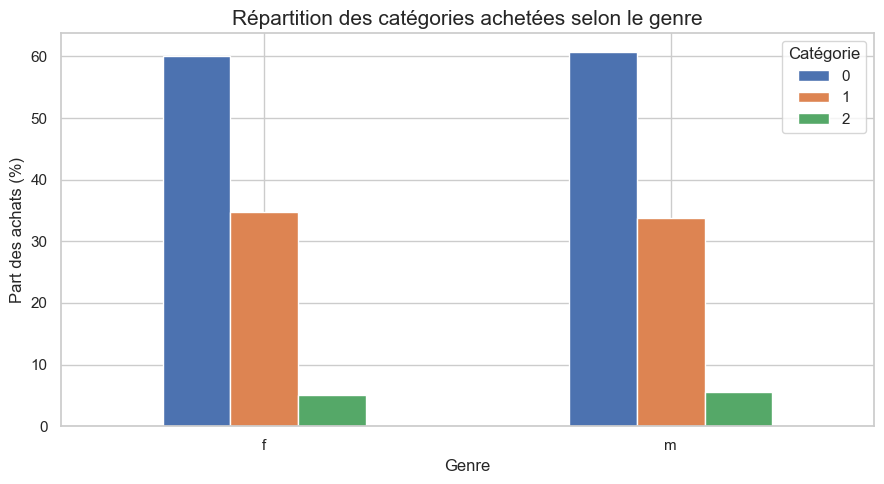

In [76]:
table_genre_categorie_pct.plot(
    kind="bar",
    figsize=(9, 5))

plt.title("Répartition des catégories achetées selon le genre", fontsize=15)
plt.xlabel("Genre")
plt.ylabel("Part des achats (%)")
plt.xticks(rotation=0)
plt.legend(title="Catégorie")
plt.tight_layout()
plt.show()

In [77]:
chi2, p_value, dof, expected = chi2_contingency(table_genre_categorie)

print(f"Statistique du Chi-2 : {chi2:.2f}")
print(f"p-value : {p_value:.4f}")
print(f"Degrés de liberté : {dof}")

Statistique du Chi-2 : 158.25
p-value : 0.0000
Degrés de liberté : 2


In [78]:
effectifs_theoriques = pd.DataFrame(expected,
    index=table_genre_categorie.index,
    columns=table_genre_categorie.columns)

display(effectifs_theoriques.round(2))

categ,0,1,2
sex,,,
f,207080.51,117427.98,18184.51
m,208378.49,118164.02,18298.49


Le test du Chi-2 met en évidence une association statistiquement significative entre le genre et les catégories achetées.  
Cette association doit ensuite être nuancée par son intensité, mesurée avec le V de Cramer.

In [79]:
# Calcul du V de Cramer
n = table_genre_categorie.values.sum()
min_dim = min(table_genre_categorie.shape) - 1

cramer_v = np.sqrt(chi2 / (n * min_dim))

print(f"V de Cramer : {cramer_v:.4f}")

V de Cramer : 0.0152


Le test du Chi-2 indique une association statistiquement significative entre le genre et les catégories achetées.  
Cependant, le V de Cramer est très faible, avec une valeur de 0,0152.

L’association existe donc statistiquement, mais reste très limitée en pratique.  
Le genre ne semble pas être une variable fortement déterminante pour expliquer les différences de comportement d’achat par catégorie.

### 8.3 Âge des clients et montant total des achats

Cette analyse étudie le lien entre l’âge des clients et le montant total de leurs achats.

Les deux variables étant numériques, l’analyse s’appuie sur un graphique de dispersion, puis sur les corrélations de Pearson et de Spearman.  
Spearman complète Pearson en limitant davantage l’influence des valeurs atypiques.

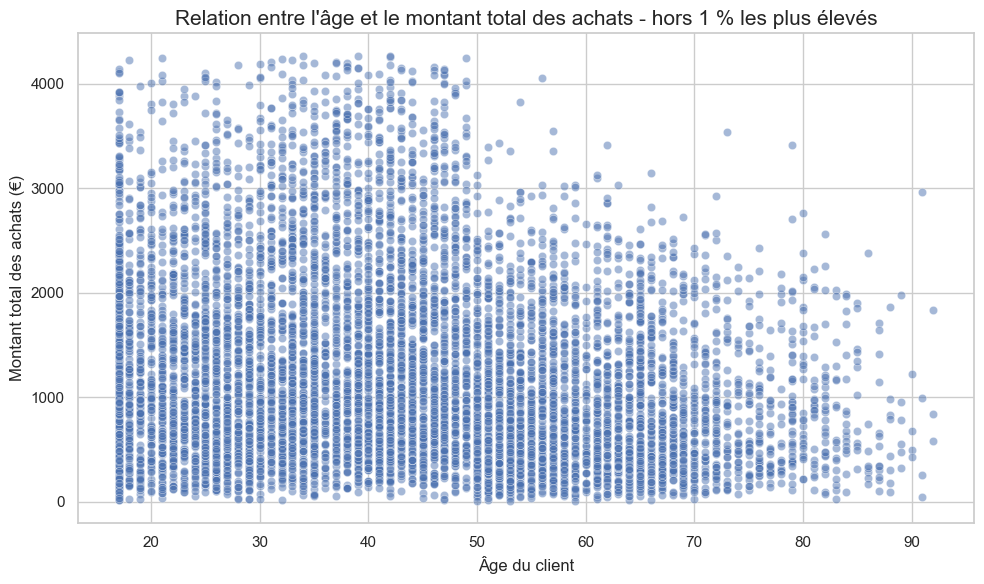

In [80]:
seuil_99_ca = variables_clients["chiffre_affaires_total"].quantile(0.99)

clients_sans_extremes = variables_clients[
    variables_clients["chiffre_affaires_total"] <= seuil_99_ca]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clients_sans_extremes,
    x="age",
    y="chiffre_affaires_total",
    alpha=0.5)

plt.title("Relation entre l'âge et le montant total des achats - hors 1 % les plus élevés", fontsize=15)
plt.xlabel("Âge du client")
plt.ylabel("Montant total des achats (€)")
plt.tight_layout()
plt.show()

In [81]:
df_ventes.loc[df_ventes["birth"] == 1929, ["date", "annee", "birth", "age"]].sort_values("date").head()

,date,annee,birth,age
9539,2021-03-11 04:57:20.717721,2021,1929,92
22854,2021-03-25 15:36:17.618993,2021,1929,92
27566,2021-03-30 20:47:44.684387,2021,1929,92
34066,2021-04-06 19:18:10.327181,2021,1929,92
34183,2021-04-06 22:05:18.918284,2021,1929,92


In [82]:
df_ventes.loc[df_ventes["age"] == df_ventes["age"].max(), ["date", "annee", "birth", "age", "categ"]].head()

,date,annee,birth,age,categ
634476,2023-01-02 13:34:50.496562,2023,1929,94,0
634685,2023-01-02 19:40:03.661341,2023,1929,94,1
634725,2023-01-02 20:39:15.237449,2023,1929,94,0
634736,2023-01-02 20:56:20.889744,2023,1929,94,0
636057,2023-01-04 05:22:59.827126,2023,1929,94,0


In [83]:
correlation_pearson_age_ca, p_value_pearson_age_ca = pearsonr(
    variables_clients["age"],
    variables_clients["chiffre_affaires_total"])

correlation_spearman_age_ca, p_value_spearman_age_ca = spearmanr(
    variables_clients["age"],
    variables_clients["chiffre_affaires_total"])

print(f"Corrélation de Pearson : {correlation_pearson_age_ca:.4f}")
print(f"p-value Pearson : {p_value_pearson_age_ca:.4f}")

print(f"Corrélation de Spearman : {correlation_spearman_age_ca:.4f}")
print(f"p-value Spearman : {p_value_spearman_age_ca:.4f}")

Corrélation de Pearson : -0.0398
p-value Pearson : 0.0002
Corrélation de Spearman : -0.1846
p-value Spearman : 0.0000


Le nuage de points ne met pas en évidence de relation linéaire forte entre l’âge des clients et le montant total des achats.  
Les montants restent très dispersés, ce qui montre que des clients d’âges similaires peuvent avoir des comportements d’achat différents.

La corrélation de Pearson est de -0,0398, indiquant une relation linéaire quasiment nulle.  
La corrélation de Spearman est de -0,1846, ce qui traduit une relation négative faible.

Même si les p-values sont inférieures à 5 %, l’intensité des corrélations reste faible.  
L’âge ne permet donc pas, à lui seul, d’expliquer le montant total des achats.

Cette relation doit être interprétée comme une association statistique faible, et non comme une relation causale.

### 8.4 Âge des clients et fréquence d’achat

Cette analyse étudie le lien entre l’âge des clients et leur fréquence d’achat, mesurée par le nombre de transactions réalisées sur la période.

Les deux variables étant numériques, l’analyse s’appuie sur un graphique de dispersion et sur les corrélations de Pearson et de Spearman.

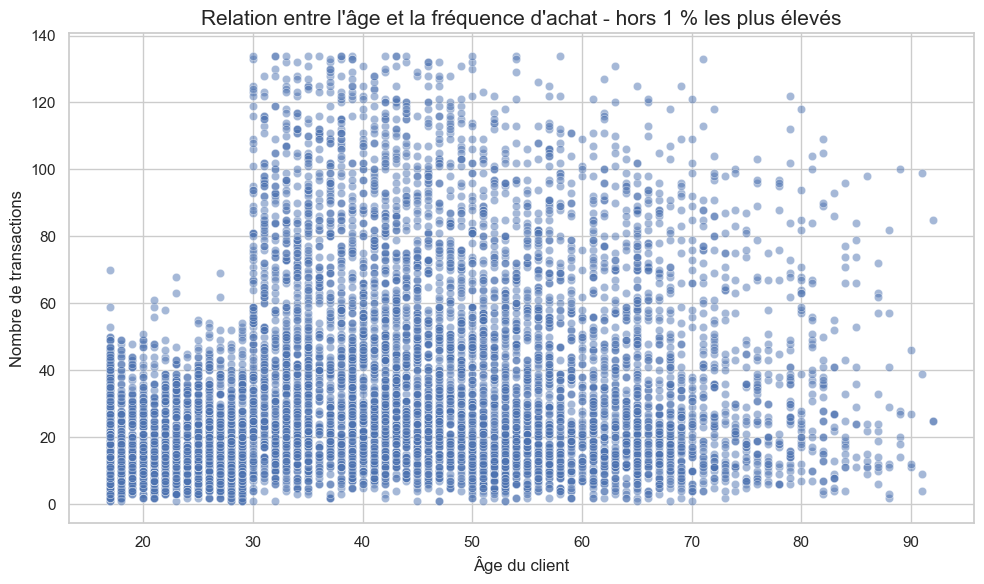

In [84]:
seuil_99_transactions = variables_clients["nombre_transactions"].quantile(0.99)

clients_sans_extremes_transactions = variables_clients[
    variables_clients["nombre_transactions"] <= seuil_99_transactions]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clients_sans_extremes_transactions,
    x="age",
    y="nombre_transactions",
    alpha=0.5)

plt.title("Relation entre l'âge et la fréquence d'achat - hors 1 % les plus élevés", fontsize=15)
plt.xlabel("Âge du client")
plt.ylabel("Nombre de transactions")
plt.tight_layout()
plt.show()

In [85]:
correlation_pearson_age_freq, p_value_pearson_age_freq = pearsonr(
    variables_clients["age"],
    variables_clients["nombre_transactions"])

correlation_spearman_age_freq, p_value_spearman_age_freq = spearmanr(
    variables_clients["age"],
    variables_clients["nombre_transactions"])

print(f"Corrélation de Pearson : {correlation_pearson_age_freq:.4f}")
print(f"p-value Pearson : {p_value_pearson_age_freq:.4f}")

print(f"Corrélation de Spearman : {correlation_spearman_age_freq:.4f}")
print(f"p-value Spearman : {p_value_spearman_age_freq:.4f}")

Corrélation de Pearson : 0.0341
p-value Pearson : 0.0016
Corrélation de Spearman : 0.2116
p-value Spearman : 0.0000


Le nuage de points montre une forte dispersion du nombre de transactions selon l’âge.  
La relation n’apparaît pas linéaire, même si une légère tendance positive peut être observée.

La corrélation de Pearson est de 0,0341, indiquant une relation linéaire quasiment nulle.  
La corrélation de Spearman est de 0,2116, ce qui traduit une relation positive faible entre l’âge et la fréquence d’achat.

Même si les p-values sont inférieures à 5 %, l’intensité de la relation reste faible.  
L’âge semble donc légèrement associé à la fréquence d’achat, sans permettre d’expliquer à lui seul le nombre de transactions.

### 8.5 Âge des clients et panier moyen

Cette analyse étudie le lien entre l’âge des clients et leur panier moyen, c’est-à-dire le montant moyen dépensé par transaction.

Les corrélations de Pearson et de Spearman sont utilisées afin d’évaluer l’intensité de cette relation.

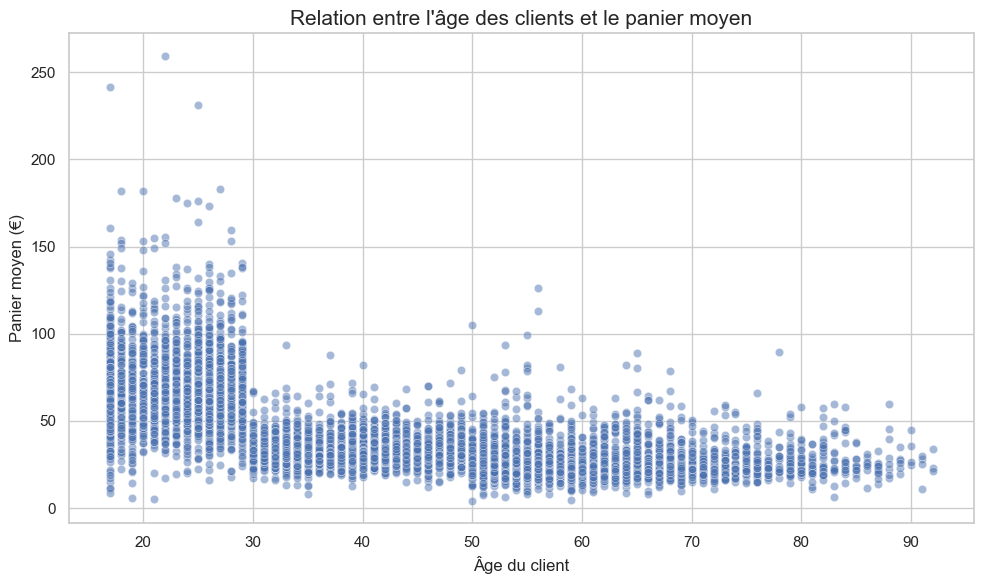

In [86]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=variables_clients,
    x="age",
    y="panier_moyen",
    alpha=0.5)

plt.title("Relation entre l'âge des clients et le panier moyen", fontsize=15)
plt.xlabel("Âge du client")
plt.ylabel("Panier moyen (€)")
plt.tight_layout()
plt.show()

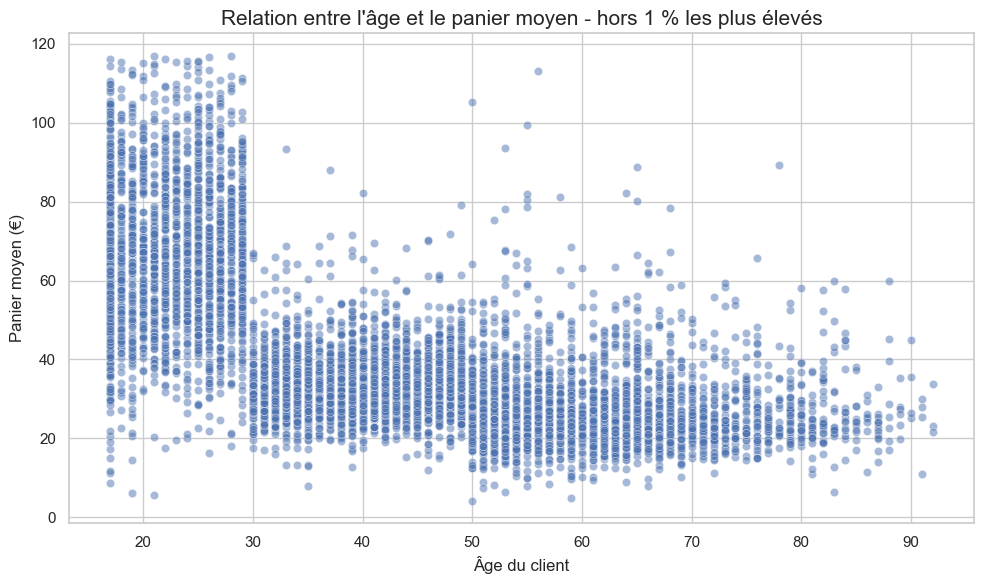

In [87]:
seuil_99_panier = variables_clients["panier_moyen"].quantile(0.99)

clients_sans_extremes_panier = variables_clients[
    variables_clients["panier_moyen"] <= seuil_99_panier]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clients_sans_extremes_panier,
    x="age",
    y="panier_moyen",
    alpha=0.5)

plt.title("Relation entre l'âge et le panier moyen - hors 1 % les plus élevés", fontsize=15)
plt.xlabel("Âge du client")
plt.ylabel("Panier moyen (€)")
plt.tight_layout()
plt.show()

In [88]:
correlation_pearson_age_panier, p_value_pearson_age_panier = pearsonr(
    variables_clients["age"],
    variables_clients["panier_moyen"])

correlation_spearman_age_panier, p_value_spearman_age_panier = spearmanr(
    variables_clients["age"],
    variables_clients["panier_moyen"])

print(f"Corrélation de Pearson : {correlation_pearson_age_panier:.4f}")
print(f"p-value Pearson : {p_value_pearson_age_panier:.4f}")

print(f"Corrélation de Spearman : {correlation_spearman_age_panier:.4f}")
print(f"p-value Spearman : {p_value_spearman_age_panier:.4f}")

Corrélation de Pearson : -0.6165
p-value Pearson : 0.0000
Corrélation de Spearman : -0.7004
p-value Spearman : 0.0000


Le nuage de points met en évidence une relation décroissante entre l’âge des clients et le panier moyen.  
Les clients les plus jeunes présentent des paniers moyens plus élevés et plus dispersés, tandis que le panier moyen tend à diminuer avec l’âge.

La corrélation de Pearson est de -0,6165 et la corrélation de Spearman de -0,7004.  
Ces résultats indiquent une relation négative forte entre l’âge et le panier moyen.

Les p-values étant inférieures à 5 %, la relation est statistiquement significative.  
L’âge apparaît donc comme une variable fortement associée au panier moyen, sans permettre de conclure à une relation de causalité.

### 8.6 Âge des clients et catégories achetées

Cette analyse étudie le lien entre l’âge des clients et leur catégorie principale d’achat.

Avant d’utiliser une ANOVA, ses conditions d’application sont vérifiées : normalité des distributions d’âge par catégorie et homogénéité des variances entre les groupes.  
Ces conditions sont analysées à l’aide de visualisations, du test de Jarque-Bera et du test de Levene.

Si ces conditions ne sont pas respectées, le test non paramétrique de Kruskal-Wallis est privilégié pour comparer les distributions d’âge entre les catégories.

In [89]:
# Calcul du chiffre d'affaires par client et par catégorie
ca_client_categorie = (
    df_ventes
    .groupby(["client_id", "categ"])
    .agg(chiffre_affaires_categorie=("chiffre_affaires", "sum")).reset_index())

# Identification de la catégorie principale de chaque client
categorie_principale_client = (
    ca_client_categorie
    .sort_values(["client_id", "chiffre_affaires_categorie"], ascending=[True, False])
    .drop_duplicates(subset="client_id")
    .rename(columns={"categ": "categorie_principale"}))

# Ajout de la catégorie principale à la base client
base_clients_anova = base_clients.merge(
    categorie_principale_client[["client_id", "categorie_principale"]],
    on="client_id",
    how="left")

display(base_clients_anova.head())

,client_id,sex,birth,age,chiffre_affaires_total,nombre_transactions,nombre_produits_achetes,panier_moyen,categorie_principale
0,c_1,m,1955,66,629.02,34,43,18.50,0
1,c_10,m,1956,65,1353.60,34,58,39.81,1
2,c_100,m,1992,29,254.85,5,8,50.97,2
3,c_1000,f,1966,55,2291.88,94,126,24.38,1
4,c_1001,m,1982,39,1823.85,47,103,38.81,0


In [90]:
base_clients_anova.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   client_id                8600 non-null   object 
 1   sex                      8600 non-null   object 
 2   birth                    8600 non-null   int64  
 3   age                      8600 non-null   int64  
 4   chiffre_affaires_total   8600 non-null   float64
 5   nombre_transactions      8600 non-null   int64  
 6   nombre_produits_achetes  8600 non-null   int64  
 7   panier_moyen             8600 non-null   float64
 8   categorie_principale     8600 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 604.8+ KB


In [91]:
base_clients_anova["categorie_principale"].isna().sum()

np.int64(0)

In [92]:
age_par_categorie_principale = (
    base_clients_anova
    .groupby("categorie_principale")["age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2))

display(age_par_categorie_principale)

,count,mean,median,std,min,max
categorie_principale,,,,,,
0,3075,40.61,40.00,8.26,17,87
1,3508,55.71,57.00,14.97,17,92
2,2017,23.44,23.00,7.27,17,84


La catégorie principale d’achat correspond, pour chaque client, à la catégorie la plus représentée dans ses achats sur la période étudiée.

Cette variable permet de résumer le comportement dominant de chaque client afin de comparer les distributions d’âge entre les catégories.

#### 8.6.1 Visualisation de la relation entre âge et catégorie principale

##### 8.6.1.1 Boxplot de l’âge par catégorie principale

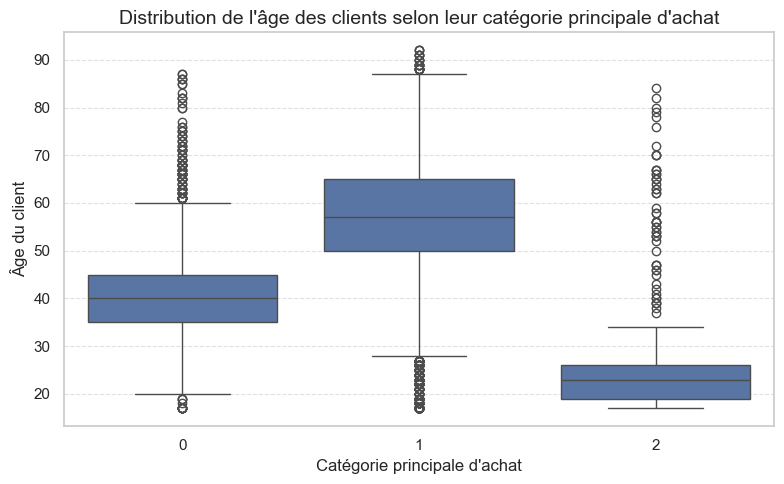

In [93]:
#### Visualisation par boxplot

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=base_clients_anova,
    x="categorie_principale",
    y="age")

plt.title("Distribution de l'âge des clients selon leur catégorie principale d'achat", fontsize=14)
plt.xlabel("Catégorie principale d'achat")
plt.ylabel("Âge du client")

plt.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
plt.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

Le boxplot permet d’observer une première différence de distribution de l’âge selon la catégorie principale d’achat.

##### 8.6.1.2 Distribution de l’âge par catégorie principale

Le graphique de densité complète le boxplot en montrant que les distributions d’âge diffèrent selon la catégorie principale d’achat et ne semblent pas suivre une loi normale.

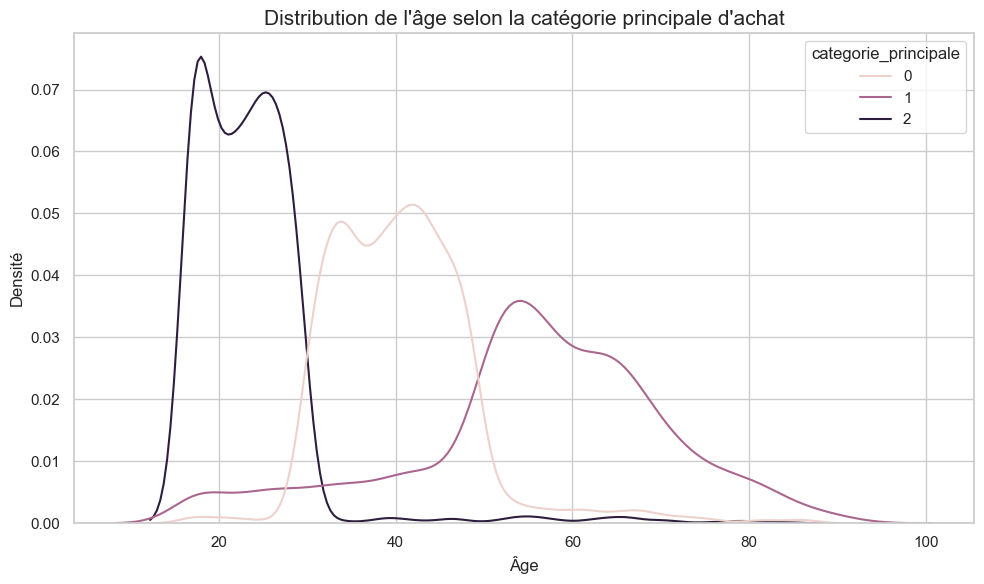

In [94]:
#### Visualisation par densité

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=base_clients_anova,
    hue="categorie_principale",
    x="age",
    common_norm=False)

plt.title("Distribution de l'âge selon la catégorie principale d'achat", fontsize=15)
plt.xlabel("Âge")
plt.ylabel("Densité")
plt.tight_layout()
plt.show()

#### 8.6.2 Vérification des conditions d’application de l’ANOVA

L’ANOVA permet de comparer l’âge moyen des clients entre plusieurs catégories principales d’achat.  
Avant de l’utiliser, il est nécessaire de vérifier la normalité des distributions et l’homogénéité des variances entre les groupes.

Ces conditions sont évaluées avec le test de Jarque-Bera et le test de Levene.

##### 8.6.2.1 Test de normalité — Jarque-Bera

Le test de Jarque-Bera est utilisé pour vérifier si la distribution de l’âge peut être considérée comme normale dans chaque catégorie principale.  
Il est appliqué séparément à chaque groupe afin d’évaluer la condition de normalité nécessaire à l’utilisation d’une ANOVA.

In [95]:
#### Vérification de la normalité

from scipy.stats import jarque_bera

resultats_jarque_bera = []

for categorie, groupe in base_clients_anova.groupby("categorie_principale"):
    stat, p_value = jarque_bera(groupe["age"].dropna())
    
    resultats_jarque_bera.append({
        "categorie_principale": categorie,
        "statistique_JB": stat,
        "p_value": p_value})

resultats_jarque_bera = pd.DataFrame(resultats_jarque_bera)

display(resultats_jarque_bera)

,categorie_principale,statistique_JB,p_value
0,0,4030.83,0.00
1,1,197.70,0.00
2,2,44551.72,0.00


Le test de Jarque-Bera rejette l’hypothèse de normalité pour chaque catégorie principale.  
La condition de normalité nécessaire à l’ANOVA n’est donc pas respectée.

##### 8.6.2.2 Test d’homogénéité des variances — Levene

Le test de Levene est utilisé pour vérifier si les variances de l’âge sont homogènes entre les catégories principales.  
Il est d’abord réalisé de manière globale, puis complété par des comparaisons entre paires de catégories afin d’identifier les écarts éventuels.

In [96]:
#### Vérification de l’homogénéité des variances

from scipy.stats import levene

groupes_age = [
    groupe["age"].dropna()
    for _, groupe in base_clients_anova.groupby("categorie_principale")]

stat_levene, p_value_levene = levene(*groupes_age, center="median")

print(f"Statistique de Levene : {stat_levene:.4f}")
print(f"p-value : {p_value_levene:.4f}")

Statistique de Levene : 615.7551
p-value : 0.0000


In [97]:
#Test de Levene pour toutes les combinaisons

from itertools import combinations

resultats_levene_paires = []

categories = base_clients_anova["categorie_principale"].dropna().unique()

for cat1, cat2 in combinations(categories, 2):
    groupe1 = base_clients.loc[
        base_clients_anova["categorie_principale"] == cat1,
        "age"].dropna()
    
    groupe2 = base_clients.loc[
        base_clients_anova["categorie_principale"] == cat2,
        "age"].dropna()
    
    stat, p_value = levene(groupe1, groupe2, center="median")
    
    resultats_levene_paires.append({
        "comparaison": f"{cat1} vs {cat2}",
        "statistique_Levene": stat,
        "p_value": p_value})

resultats_levene_paires = pd.DataFrame(resultats_levene_paires)

display(resultats_levene_paires)

,comparaison,statistique_Levene,p_value
0,0 vs 1,649.75,0.00
1,0 vs 2,96.82,0.00
2,1 vs 2,785.63,0.00


Le test de Levene indique que l’homogénéité des variances n’est pas pleinement respectée entre les catégories principales.  
Ce résultat, associé au rejet de la normalité, confirme que les conditions d’application de l’ANOVA ne sont pas réunies.

#### 8.6.3 Test non paramétrique de Kruskal-Wallis

Les conditions d’application de l’ANOVA n’étant pas respectées, le test non paramétrique de Kruskal-Wallis est utilisé pour comparer les distributions d’âge entre les catégories principales.

##### 8.6.3.1 Test global de Kruskal-Wallis

Les tests précédents montrent que les conditions d’application de l’ANOVA ne sont pas respectées.  
Un test non paramétrique de Kruskal-Wallis est donc utilisé afin de comparer les distributions d’âge entre les catégories principales d’achat.

Ce test permet d’évaluer s’il existe une différence statistiquement significative entre au moins deux catégories.

In [98]:
#### Comparaison des distributions

from scipy.stats import kruskal

stat_kruskal, p_value_kruskal = kruskal(*groupes_age)

print(f"Statistique de Kruskal-Wallis : {stat_kruskal:.4f}")
print(f"p-value : {p_value_kruskal:.4f}")

Statistique de Kruskal-Wallis : 5073.3689
p-value : 0.0000


Le test de Kruskal-Wallis met en évidence une différence globale significative entre les catégories principales.  
Des comparaisons deux à deux sont ensuite réalisées afin d’identifier les catégories concernées par ces différences.

##### 8.6.3.2 Comparaisons deux à deux entre catégories principales

Des comparaisons deux à deux sont réalisées afin d’identifier entre quelles catégories les distributions d’âge diffèrent significativement.  
Les p-values sont corrigées avec la méthode de Bonferroni pour tenir compte des comparaisons multiples.

In [99]:
#Des tests de Mann-Whitney sont réalisés deux à deux entre les catégories principales pour préciser les différences identifiées par le test de Kruskal-Wallis.  
#Une correction de Bonferroni est appliquée afin de tenir compte des comparaisons multiples.

from itertools import combinations
from scipy.stats import mannwhitneyu

resultats_mannwhitney = []

categories = sorted(base_clients_anova["categorie_principale"].dropna().unique())

for cat1, cat2 in combinations(categories, 2):
    groupe1 = base_clients_anova.loc[
        base_clients_anova["categorie_principale"] == cat1,
        "age"].dropna()
    
    groupe2 = base_clients_anova.loc[
        base_clients_anova["categorie_principale"] == cat2,
        "age"].dropna()
    
    stat, p_value = mannwhitneyu(
        groupe1,
        groupe2,
        alternative="two-sided")
    
    resultats_mannwhitney.append({
        "comparaison": f"{cat1} vs {cat2}",
        "statistique": stat,
        "p_value": p_value})

resultats_mannwhitney = pd.DataFrame(resultats_mannwhitney)

# Correction de Bonferroni
resultats_mannwhitney["p_value_corrigee"] = (
    resultats_mannwhitney["p_value"] * len(resultats_mannwhitney)).clip(upper=1)

display(resultats_mannwhitney)

,comparaison,statistique,p_value,p_value_corrigee
0,0 vs 1,1856263.00,0.00,0.00
1,0 vs 2,6016152.00,0.00,0.00
2,1 vs 2,6702872.00,0.00,0.00


Les tests de Mann-Whitney réalisés deux à deux montrent que les distributions d’âge diffèrent significativement entre toutes les catégories principales d’achat.  
Les p-values corrigées par la méthode de Bonferroni restent inférieures à 5 % pour les trois comparaisons : 0 vs 1, 0 vs 2 et 1 vs 2.

Ces résultats précisent la conclusion du test de Kruskal-Wallis : les catégories principales d’achat sont associées à des profils d’âge distincts.  
Cette relation reste toutefois une association statistique et ne permet pas de conclure à une relation de causalité.

#### 8.6.4 Analyse complémentaire par classes d’âge

En complément de l’analyse statistique par catégorie principale, l’âge est regroupé en classes afin de faciliter l’interprétation business des comportements d’achat.

Cette lecture permet d’observer la répartition des catégories achetées selon les grandes tranches d’âge de clients.


In [100]:
# Création de classes d'âge
df_ventes["classe_age"] = pd.cut(
    df_ventes["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"])

# Vérification
display(df_ventes[["age", "classe_age"]].head())

,age,classe_age
0,54,46-55
1,61,56-65
2,33,26-35
3,32,26-35
4,65,56-65


In [101]:
table_age_categorie = pd.crosstab(
    df_ventes["classe_age"],
    df_ventes["categ"])

display(table_age_categorie)

categ,0,1,2
classe_age,,,
18-25,11256,21803,22998
26-35,85270,35025,10594
36-45,177748,56680,759
46-55,89967,54313,1058
56-65,27823,36506,577
66+,23395,31265,497


In [102]:
table_age_categorie_pct = pd.crosstab(
    df_ventes["classe_age"],
    df_ventes["categ"],
    normalize="index") * 100

display(table_age_categorie_pct.round(2))

categ,0,1,2
classe_age,,,
18-25,20.08,38.89,41.03
26-35,65.15,26.76,8.09
36-45,75.58,24.10,0.32
46-55,61.90,37.37,0.73
56-65,42.87,56.24,0.89
66+,42.42,56.68,0.90


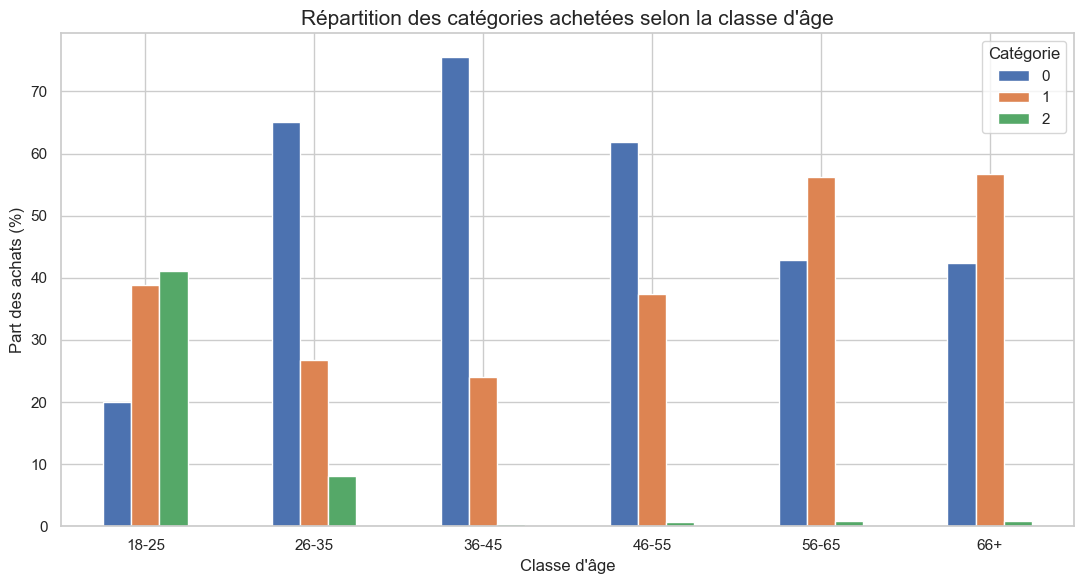

In [103]:
table_age_categorie_pct.plot(
    kind="bar",
    figsize=(11, 6))

plt.title("Répartition des catégories achetées selon la classe d'âge", fontsize=15)
plt.xlabel("Classe d'âge")
plt.ylabel("Part des achats (%)")
plt.xticks(rotation=0)
plt.legend(title="Catégorie")
plt.tight_layout()
plt.show()

L’analyse par classes d’âge montre des profils d’achat différenciés selon l’âge.  
Les 18-25 ans se distinguent par une forte part d’achats en catégorie 2, tandis que les 26-55 ans sont davantage orientés vers la catégorie 0.

À partir de 56 ans, la catégorie 1 devient majoritaire.  
Cette lecture complète les tests statistiques précédents en apportant une interprétation plus opérationnelle des différences observées.

### 8.7 Synthèse des analyses statistiques

Les analyses statistiques montrent que le genre est peu discriminant : l’association avec les catégories achetées est significative, mais de très faible intensité.

L’âge apparaît en revanche comme une variable plus structurante.  
Il est faiblement associé au montant total des achats et à la fréquence d’achat, mais fortement associé au panier moyen, qui tend à diminuer avec l’âge.

L’âge est également lié aux catégories principalement achetées : les profils plus jeunes sont davantage associés à la catégorie 2, tandis que les profils plus âgés sont davantage associés à la catégorie 1.

Ces résultats doivent être interprétés comme des associations statistiques, et non comme des relations de causalité.

## 9. Synthèse générale et recommandations

Cette section synthétise les principaux enseignements de l’analyse et propose des recommandations opérationnelles pour le pilotage des ventes, la segmentation client et l’amélioration de la performance commerciale.

### 9.1 Synthèse des principaux constats

L’activité en ligne de Lapage apparaît globalement stable sur la période étudiée.  
Les variations mensuelles du chiffre d’affaires semblent principalement liées au volume de transactions, notamment en février 2023, où le panier moyen reste relativement stable.

Les catégories ne contribuent pas de manière équivalente au chiffre d’affaires.  
La catégorie 1 est la plus contributrice, suivie de près par la catégorie 0, tandis que la catégorie 2 présente une contribution plus limitée.

L’analyse produit montre que les références générant le plus de chiffre d’affaires ne sont pas nécessairement les plus vendues en volume.  
Cette différence s’explique notamment par le prix unitaire plus élevé des produits du top chiffre d’affaires.

Au niveau client, le chiffre d’affaires présente une certaine concentration.  
Les clients atypiques représentent une faible part de la base, mais contribuent significativement au chiffre d’affaires total. Ils constituent des profils à suivre, sans être qualifiés formellement de BtoB en l’absence de variable dédiée.

Enfin, les analyses statistiques montrent que l’âge est plus structurant que le genre pour comprendre certains comportements d’achat.  
Il est notamment associé au panier moyen et aux catégories principalement achetées.

### 9.2 Recommandations opérationnelles

À partir des résultats obtenus, plusieurs recommandations peuvent être formulées.

Premièrement, il serait pertinent de suivre plus finement les variations du volume de transactions, car elles expliquent une partie importante des évolutions du chiffre d’affaires.  
La baisse de février 2023 pourrait faire l’objet d’une analyse complémentaire afin d’identifier d’éventuels facteurs opérationnels ou marketing : trafic sur le site, campagnes promotionnelles, disponibilité des produits, saisonnalité ou performance par catégorie.

Deuxièmement, les actions marketing pourraient être adaptées selon les profils d’âge.  
Les analyses montrent que les clients plus jeunes sont davantage associés à la catégorie 2, tandis que les clients plus âgés sont davantage associés à la catégorie 1.  
Cette information peut aider à mieux cibler les offres, les recommandations produits ou les campagnes de communication.

Troisièmement, il est recommandé de distinguer les produits à fort chiffre d’affaires des produits à fort volume.  
Les premiers contribuent fortement aux revenus grâce à leur prix unitaire plus élevé, tandis que les seconds traduisent une forte fréquence d’achat.  
Ces deux types de produits peuvent faire l’objet de stratégies commerciales différentes.

Enfin, les clients très contributeurs doivent faire l’objet d’un suivi spécifique.  
Certains profils présentent des volumes d’achat très élevés et pourraient correspondre à des usages professionnels, institutionnels ou spécifiques.  
Il serait donc utile d’enrichir la base clients avec une variable permettant d’identifier le type de client, par exemple BtoB ou BtoC.

### 9.3 Limites de l’analyse

Certaines limites doivent être prises en compte dans l’interprétation des résultats.

Tout d’abord, les données disponibles ne permettent pas d’identifier directement les clients BtoB.  
Les profils atypiques ont été repérés à partir du chiffre d’affaires, du nombre de transactions et du volume de produits achetés, mais ils ne peuvent pas être qualifiés formellement de clients professionnels sans variable dédiée.

Ensuite, les analyses statistiques mettent en évidence des associations entre variables, mais ne permettent pas d’établir des relations de causalité.  
Par exemple, l’âge est associé au panier moyen et à la catégorie principale d’achat, mais cela ne signifie pas que l’âge explique à lui seul ces comportements.

L’âge est également estimé à partir de l’année de naissance et de l’année de transaction.  
Il s’agit donc d’un âge calculé en années civiles, ce qui constitue une approximation.

Enfin, certaines variations observées, comme la baisse du chiffre d’affaires en février 2023, nécessiteraient des données complémentaires pour être expliquées précisément : trafic du site, campagnes marketing, stocks ou promotions.

### 9.4 Pistes d’approfondissement

Plusieurs pistes pourraient être explorées pour approfondir l’analyse.

Une première piste consisterait à enrichir la base clients avec une typologie BtoB / BtoC.  
Cette information permettrait de distinguer les comportements des clients particuliers et professionnels, d’évaluer leur poids respectif dans le chiffre d’affaires et d’adapter les actions commerciales.

Une deuxième piste serait d’analyser plus finement la baisse de février 2023.  
L’analyse réalisée montre que cette baisse est principalement liée à une diminution du nombre de transactions, mais les causes exactes nécessiteraient des données opérationnelles complémentaires.

Une troisième piste consisterait à approfondir l’analyse des catégories principales d’achat selon les profils clients.  
L’âge apparaissant comme une variable structurante, une analyse plus fine des segments d’âge, des catégories achetées et des paniers moyens pourrait aider à mieux cibler les actions marketing.

Une quatrième piste serait d’analyser plus précisément les clients atypiques afin de mieux comprendre s’ils correspondent à des clients professionnels, institutionnels, très fidèles ou à des comportements d’achat spécifiques.

Il serait également intéressant d’analyser les clients inscrits sans transaction.  
Même s’ils sont peu nombreux, ces profils pourraient aider à comprendre certains freins à la conversion entre inscription et premier achat, à condition de disposer de données complémentaires comme la date d’inscription, le canal d’acquisition ou les paniers abandonnés.

Enfin, un suivi régulier des indicateurs clés pourrait être mis en place : chiffre d’affaires mensuel, nombre de transactions, panier moyen, clients actifs, top produits, catégories principales d’achat et contribution des clients atypiques.

<div style="background-color:#eef5ff; color:#0b2c4d; padding:14px; border-left:5px solid #2f80ed; border-radius:6px;">

<h3>Limites et pistes d’approfondissement CODIR</h3>

<ul>
  <li>Intégrer les données de marge afin de distinguer chiffre d’affaires et rentabilité réelle.</li>
  <li>Croiser les ventes avec les données de stock pour identifier d’éventuelles ruptures ou effets de disponibilité.</li>
  <li>Mettre en place un suivi S&amp;OP afin d’aligner ventes, marketing, stocks et prévisions.</li>
  <li>Enrichir la base clients avec une typologie BtoB / BtoC pour mieux piloter les segments commerciaux.</li>
</ul>

</div>